In [12]:
%load_ext autoreload
%autoreload 2

import os
import sys
import random
import joblib
from pathlib import Path
from aerosandbox import Airfoil, KulfanAirfoil

# Find the project root (the nearest ancestor that contains `src`) and add it to sys.path
cwd = Path.cwd()
project_root = cwd
for _ in range(6):
    if (project_root / "src").exists():
        break
    if project_root.parent == project_root:
        break
    project_root = project_root.parent
else:
    project_root = cwd

proj_path = str(project_root.resolve())
if proj_path not in sys.path:
    # Insert at front so local packages take precedence
    sys.path.insert(0, proj_path)

import tensorflow as tf
import numpy as np
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import wandb
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import Image, display

from src.vae import CSTVariationalAutoencoder
from src.plotting import plot_original_and_reconstruction
from src.scalers.airfoil_scaler import AirfoilScaler
from src.plotting import *
from src.utils import compute_vod_loss, compute_vod_numpy

from src.airfoil import airfoil_modifications

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# ============================================================================
# USER INPUTS
# ============================================================================

# 1. The timestamp folder name in models/cstvae/
RUN_ID = "20260516-232746"  

# 2. The specific epoch number to load
EPOCH = 100

# 3. Model Hyperparameters (Must match what was used in training)
NPV = 8
LATENT_DIM = 10

# 4. Number of airfoils to plot during validation
AIRFOILS_TO_PLOT = 25

# Paths
BASE_DIR = Path(proj_path) # Project Root
MODELS_DIR = BASE_DIR / "models" / "cstvae" / RUN_ID
WEIGHTS_PATH = MODELS_DIR / "weights" / f"vae_weights_epoch_{EPOCH}.weights.h5"
SCALER_PATH = MODELS_DIR / "scaler" / "scaler.pkl"
TRAIN_DATA_PATH = BASE_DIR / "data" / "processed" / "train_kulfan_dataset_8.json"
DATA_PATH = BASE_DIR / "data" / "processed" / "val_kulfan_dataset_8.json"

print(f"Loading model from: {RUN_ID}")
print(f"Weights file: {WEIGHTS_PATH}")

Loading model from: 20260516-232746
Weights file: /home/matsouto/Documents/py/AeroGen/models/cstvae/20260516-232746/weights/vae_weights_epoch_100.weights.h5


In [14]:
# 1. Load the Scaler
if not SCALER_PATH.exists():
    raise FileNotFoundError(f"Scaler not found at {SCALER_PATH}")

print("Loading Scaler...")
scaler = joblib.load(SCALER_PATH)

# 2. Instantiate the VAE Model
print("Building VAE Architecture...")
vae = CSTVariationalAutoencoder(scaler=scaler, npv=NPV, latent_dim=LATENT_DIM)

# 3. Run a dummy forward pass to initialize the graph
# (TensorFlow needs to know input shape to build layers before loading weights)
dummy_input = tf.zeros((1, (2 * NPV) + 2))
vae(dummy_input)

# 4. Load Weights
print(f"Loading Weights from Epoch {EPOCH}...")
try:
    vae.load_weights(WEIGHTS_PATH)
    print("✓ Weights loaded successfully.")
except OSError as e:
    print(f"❌ Error loading weights: {e}")
    print("Check if the file path is correct.")

Loading Scaler...
Building VAE Architecture...
Loading Weights from Epoch 100...
✓ Weights loaded successfully.


/home/matsouto/Documents/py/AeroGen/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/matsouto/Documents/py/AeroGen/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'decoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [15]:
# 1. Load Dataframe
print("Loading Validation Dataset...")
val_df = pd.read_json(DATA_PATH)

# 2. Select First 9 Airfoils
val_sample = val_df.iloc[:AIRFOILS_TO_PLOT].copy().reset_index(drop=True)

# 3. Helper to format coordinates
val_sample["coordinates"] = val_sample["coordinates"].apply(np.array)

# 4. Extract Kulfan Parameters (Exact logic from train.py)
# Note: Ensure order (lower vs upper) matches your training script exactly
raw_vectors = val_sample["kulfan_parameters"].apply(
  lambda p: np.concatenate([
    p["upper_weights"],     # Upper
    p["lower_weights"],     # Lower
    [p["TE_thickness"]],    # TE
    [p["leading_edge_weight"]] # LE
    ], axis=0)).to_list()

# 5. Normalize
raw_tensor = tf.convert_to_tensor(raw_vectors, dtype=tf.float32)
weights_raw = raw_tensor[:, : 2 * NPV]
params_raw = raw_tensor[:, 2 * NPV :]
input_normalized = scaler.transform(weights_raw, params_raw)

print(f"✓ Data prepared. Input shape: {input_normalized.shape}")

Loading Validation Dataset...
✓ Data prepared. Input shape: (25, 18)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Running Inference...
Preparing Airfoil objects...
Generating Plots...


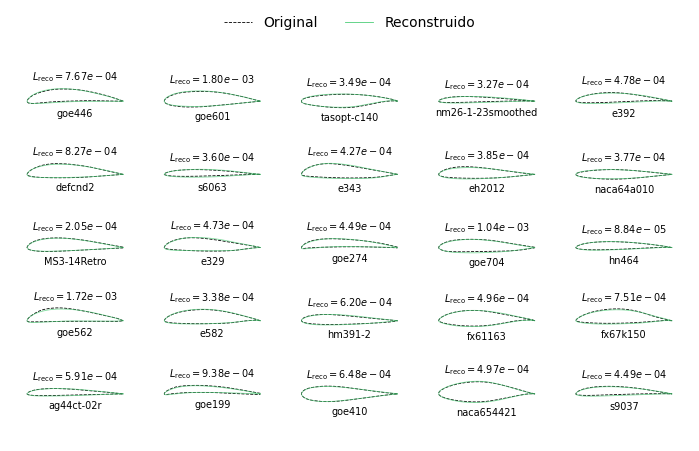

Saved reconstruction figure to: /home/matsouto/Documents/py/AeroGen/images


In [16]:
# 1. Run Inference (Reconstruction)
print("Running Inference...")
# training=False removes stochastic noise for validation
pred_weights_norm, pred_params_norm = vae(input_normalized, training=False)
pred_weights_norm_flat = tf.reshape(pred_weights_norm, [tf.shape(pred_weights_norm)[0], -1])
pred_normalized = tf.concat([pred_weights_norm_flat, pred_params_norm], axis=1)
reconstruction_losses = tf.reduce_mean(
    tf.square(input_normalized - pred_normalized), axis=1
).numpy()

# 2. Denormalize Predictions
pred_weights, pred_params = scaler.inverse_transform(
    pred_weights_norm.numpy(), 
    pred_params_norm.numpy()
)

# 3. Generate Coordinates via CST Layer
pred_weights_t = tf.reshape(tf.convert_to_tensor(pred_weights, dtype=tf.float32), [-1, 2, NPV])
pred_params_t = tf.convert_to_tensor(pred_params, dtype=tf.float32)
pred_coords = vae.decoder.cst_transform(
    pred_weights_t,
    pred_params_t
).numpy()

# 4. Prepare Airfoil Objects for the Plotter
print("Preparing Airfoil objects...")

# List A: Original Ground Truth Airfoils (created in Cell 4)
# (Assuming 'validation_airfoils' list was created in Cell 4 logic, 
#  if not, we recreate it here from the dataframe sample)
original_airfoils_objs = [
    Airfoil(coordinates=row["coordinates"], name=row["airfoil_name"]) 
    for _, row in val_sample.iterrows()
]
profile_labels = [af.name or f"Profile {i + 1}" for i, af in enumerate(original_airfoils_objs)]

# List B: Reconstructed Airfoils from VAE
reconstructed_airfoils_objs = []
for coords in pred_coords:
    # We assign a generic name or copy the original name for reference
    reconstructed_airfoils_objs.append(Airfoil(coordinates=coords, name="VAE Reco"))

# 5. Call Your Custom Plot Function
print("Generating Plots...")
images_dir = BASE_DIR / "images"
plot_original_and_reconstruction(
    original_airfoils_objs,       # Ground Truth
    reconstructed_airfoils_objs,  # VAE Output
    text_label=None,
    figsize=(7, 7),
    scale=1.05,
    linewidth=0.6,
    save_path=images_dir,
    filename=f"vae_validation_reconstruction_{RUN_ID}_epoch_{EPOCH}.png",
    dpi=300,
    color_reconstruction="#4ccd77",
    profile_labels=profile_labels,
    reconstruction_losses=reconstruction_losses,
    show_legend=True,
    show=True                     # Force show in notebook
)
print(f"Saved reconstruction figure to: {images_dir}")

### Reconstruction Detail

Selected profile for reconstruction detail: goe562
Saved reconstruction detail figure to: /home/matsouto/Documents/py/AeroGen/images/vae_validation_reconstruction_detail_20260516-232746_epoch_100.png


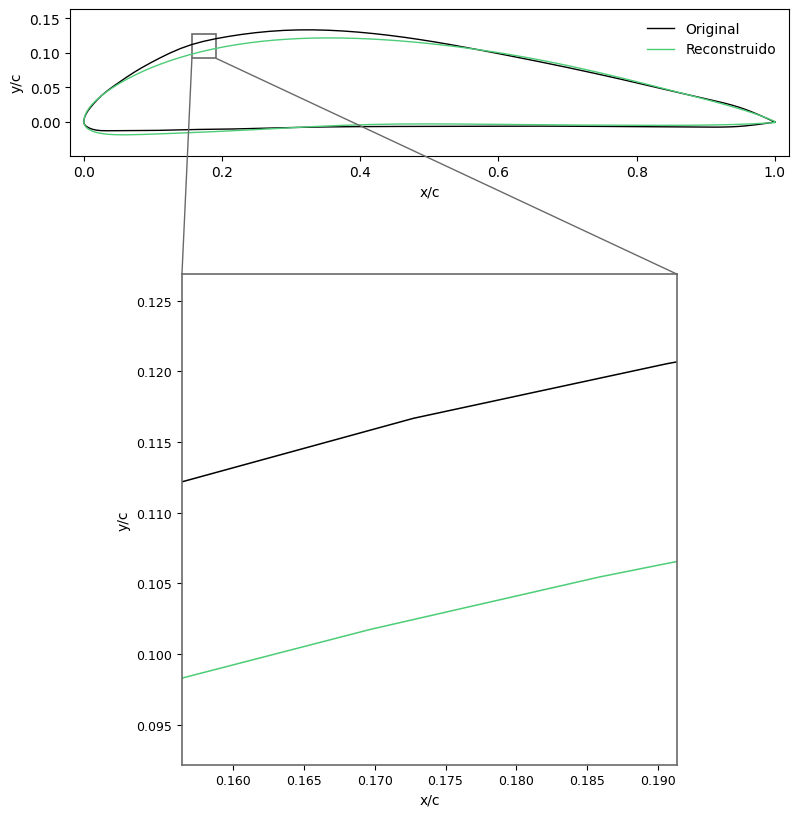

In [17]:
from matplotlib.patches import ConnectionPatch, Rectangle

def split_surfaces(coords):
    x = coords[:, 0]
    le_idx = int(np.argmin(x))

    upper = coords[:le_idx + 1][::-1]
    lower = coords[le_idx:]

    upper_order = np.argsort(upper[:, 0])
    lower_order = np.argsort(lower[:, 0])
    return upper[upper_order], lower[lower_order]

common_x = np.linspace(0.02, 0.98, 600)
best_profile_idx = None
best_peak_idx = None
best_peak_diff = -np.inf
best_interp = None

for profile_idx, (orig_af, reco_af) in enumerate(zip(original_airfoils_objs, reconstructed_airfoils_objs)):
    orig_coords = np.asarray(orig_af.coordinates)
    reco_coords = np.asarray(reco_af.coordinates)

    orig_upper, orig_lower = split_surfaces(orig_coords)
    reco_upper, reco_lower = split_surfaces(reco_coords)

    orig_upper_y = np.interp(common_x, orig_upper[:, 0], orig_upper[:, 1])
    orig_lower_y = np.interp(common_x, orig_lower[:, 0], orig_lower[:, 1])
    reco_upper_y = np.interp(common_x, reco_upper[:, 0], reco_upper[:, 1])
    reco_lower_y = np.interp(common_x, reco_lower[:, 0], reco_lower[:, 1])

    upper_diff = np.abs(orig_upper_y - reco_upper_y)
    lower_diff = np.abs(orig_lower_y - reco_lower_y)
    local_diff = np.maximum(upper_diff, lower_diff)
    peak_idx = int(np.argmax(local_diff))
    peak_diff = float(local_diff[peak_idx])

    if peak_diff > best_peak_diff:
        best_peak_diff = peak_diff
        best_profile_idx = profile_idx
        best_peak_idx = peak_idx
        focus_surface = "upper" if upper_diff[peak_idx] >= lower_diff[peak_idx] else "lower"
        best_interp = {
            "orig_upper_y": orig_upper_y,
            "orig_lower_y": orig_lower_y,
            "reco_upper_y": reco_upper_y,
            "reco_lower_y": reco_lower_y,
            "upper_diff": upper_diff,
            "lower_diff": lower_diff,
            "local_diff": local_diff,
            "focus_surface": focus_surface
        }

if best_profile_idx is None:
    raise RuntimeError("No reconstructed profiles available for detail plot.")

orig_coords = np.asarray(original_airfoils_objs[best_profile_idx].coordinates)
reco_coords = np.asarray(reconstructed_airfoils_objs[best_profile_idx].coordinates)
profile_name = original_airfoils_objs[best_profile_idx].name or f"Profile {best_profile_idx + 1}"
print(f"Selected profile for reconstruction detail: {profile_name}")

peak_x = float(common_x[best_peak_idx])
zoom_width = 0.035
zoom_x_min = min(max(peak_x - 0.5 * zoom_width, 0.0), 1.0 - zoom_width)
zoom_x_max = zoom_x_min + zoom_width
mask = (common_x >= zoom_x_min) & (common_x <= zoom_x_max)

if best_interp["focus_surface"] == "upper":
    local_y_values = np.concatenate([
        best_interp["orig_upper_y"][mask],
        best_interp["reco_upper_y"][mask]
    ])
else:
    local_y_values = np.concatenate([
        best_interp["orig_lower_y"][mask],
        best_interp["reco_lower_y"][mask]
    ])

local_y_min = float(np.min(local_y_values))
local_y_max = float(np.max(local_y_values))
local_y_span = max(local_y_max - local_y_min, 0.002)
zoom_y_padding = max(0.001, 0.3 * local_y_span)
zoom_y_min = local_y_min - zoom_y_padding
zoom_y_max = local_y_max + zoom_y_padding

profile_y_min = min(float(np.min(orig_coords[:, 1])), float(np.min(reco_coords[:, 1])))
profile_y_max = max(float(np.max(orig_coords[:, 1])), float(np.max(reco_coords[:, 1])))
profile_y_span = max(profile_y_max - profile_y_min, 0.12)
main_y_padding = max(0.03, 0.12 * profile_y_span)

images_dir = BASE_DIR / "images"
images_dir.mkdir(parents=True, exist_ok=True)
output_path = images_dir / f"vae_validation_reconstruction_detail_{RUN_ID}_epoch_{EPOCH}.png"

fig, (ax_main, ax_zoom) = plt.subplots(
    2,
    1,
    figsize=(8, 10),
    gridspec_kw={"height_ratios": [1, 1]}
 )

ax_main.plot(orig_coords[:, 0], orig_coords[:, 1], color="black", linewidth=1.0, label="Original")
ax_main.plot(reco_coords[:, 0], reco_coords[:, 1], color="#4ccd77", linewidth=1.0, label="Reconstruido")
ax_main.set_xlim(-0.02, 1.02)
ax_main.set_ylim(profile_y_min - main_y_padding, profile_y_max + main_y_padding)
ax_main.set_aspect("equal", adjustable="box")
ax_main.set_xlabel("x/c")
ax_main.set_ylabel("y/c")
ax_main.legend(loc="upper right", frameon=False)

zoom_box = Rectangle(
    (zoom_x_min, zoom_y_min),
    zoom_x_max - zoom_x_min,
    zoom_y_max - zoom_y_min,
    fill=False,
    edgecolor="dimgray",
    linewidth=1.2
 )
ax_main.add_patch(zoom_box)

ax_zoom.plot(orig_coords[:, 0], orig_coords[:, 1], color="black", linewidth=1.1, label="Original")
ax_zoom.plot(reco_coords[:, 0], reco_coords[:, 1], color="#4ccd77", linewidth=1.1, label="Reconstruido")
ax_zoom.set_xlim(zoom_x_min, zoom_x_max)
ax_zoom.set_ylim(zoom_y_min, zoom_y_max)
ax_zoom.set_aspect("equal", adjustable="box")
ax_zoom.set_xlabel("x/c")
ax_zoom.set_ylabel("y/c")
ax_zoom.tick_params(axis="both", labelsize=9)
for spine in ax_zoom.spines.values():
    spine.set_edgecolor("dimgray")
    spine.set_linewidth(1.2)

left_connector = ConnectionPatch(
    xyA=(zoom_x_min, zoom_y_min), coordsA=ax_main.transData,
    xyB=(0.0, 1.0), coordsB=ax_zoom.transAxes,
    color="dimgray", linewidth=1.0
 )
right_connector = ConnectionPatch(
    xyA=(zoom_x_max, zoom_y_min), coordsA=ax_main.transData,
    xyB=(1.0, 1.0), coordsB=ax_zoom.transAxes,
    color="dimgray", linewidth=1.0
 )
fig.add_artist(left_connector)
fig.add_artist(right_connector)

plt.tight_layout()
fig.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
print(f"Saved reconstruction detail figure to: {output_path}")
plt.show()

### Errors

In [8]:
# ============================================================================
# GLOBAL VALIDATION METRICS (WEIGHTS + GEOMETRY)
# ============================================================================

print(f"Calculating metrics for entire validation set ({len(val_df)} samples)...")

# 1. Prepare Full Input Tensor (Raw Physical Values)
# Extract all vectors using the same logic as before
all_vectors = val_df["kulfan_parameters"].apply(
  lambda p: np.concatenate([
    p["upper_weights"],     # Upper
    p["lower_weights"],     # Lower
    [p["TE_thickness"]],    # TE
    [p["leading_edge_weight"]] # LE
    ], axis=0)).to_list()

# Convert to Tensor (Physical Units)
all_tensor_phys = tf.convert_to_tensor(all_vectors, dtype=tf.float32)
all_weights_phys = all_tensor_phys[:, : 2 * NPV]
all_params_phys = all_tensor_phys[:, 2 * NPV :]

# Normalize for Model Input
all_normalized = scaler.transform(all_weights_phys, all_params_phys)

# 2. Run Inference on the whole batch
# training=False ensures deterministic output
pred_w_norm, pred_p_norm = vae(all_normalized, training=False)

# ---------------------------------------------------------
# METRIC A: WEIGHTS MAE (Mathematical Error)
# ---------------------------------------------------------
# Reshape VAE output to match input shape (Batch, (2 * NPV) + 2)
pred_w_flat = tf.reshape(pred_w_norm, [-1, 2 * NPV])
pred_combined_norm = tf.concat([pred_w_flat, pred_p_norm], axis=1)

# Calculate MAE
mae_metric = tf.keras.losses.MeanAbsoluteError()
global_mae = mae_metric(all_normalized, pred_combined_norm).numpy()

# Calculate per-sample error for histogram
errors_weights = tf.reduce_mean(tf.abs(all_normalized - pred_combined_norm), axis=1).numpy()

# ---------------------------------------------------------
# METRIC B: GEOMETRIC MAE (Physical Error)
# ---------------------------------------------------------
print("Generating coordinates for geometric error calculation...")

# A. Generate Ground Truth Coordinates
# Reshape weights to (Batch, 2, NPV) for CST Layer
true_weights_reshaped = tf.reshape(all_weights_phys, [-1, 2, NPV])
true_coords = vae.decoder.cst_transform(true_weights_reshaped, all_params_phys)

# B. Generate Predicted Coordinates
# Denormalize predictions back to physical units
pred_w_phys, pred_p_phys = vae.scaler.inverse_transform(
    pred_w_norm.numpy(), 
    pred_p_norm.numpy()
)
# Convert to Tensor and Reshape
pred_w_phys_t = tf.convert_to_tensor(pred_w_phys, dtype=tf.float32)
pred_w_phys_reshaped = tf.reshape(pred_w_phys_t, [-1, 2, NPV])
pred_p_phys_t = tf.convert_to_tensor(pred_p_phys, dtype=tf.float32)

pred_coords = vae.decoder.cst_transform(pred_w_phys_reshaped, pred_p_phys_t)

# C. Calculate Geometric MAE
# Mean absolute difference between coordinates
val_geo_mae = tf.reduce_mean(tf.abs(true_coords - pred_coords)).numpy()

# Calculate per-sample geometric error for histogram
errors_geo = tf.reduce_mean(tf.reduce_mean(tf.abs(true_coords - pred_coords), axis=1), axis=1).numpy()

# ---------------------------------------------------------
# RESULTS & PLOTTING
# ---------------------------------------------------------
print("\n" + "="*40)
print(f"GLOBAL VALIDATION RESULTS (Model: {RUN_ID})")
print("="*40)
print(f"Weights MAE (Normalized):  {global_mae:.6f}")
print(f"Geometric MAE (Physical):  {val_geo_mae:.6f}")
print("="*40)

# Plot Histograms with Plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

images_dir = BASE_DIR / "images"
images_dir.mkdir(parents=True, exist_ok=True)
output_path = images_dir / f"vae_validation_metrics_{RUN_ID}_epoch_{EPOCH}.png"
viridis_color = "#2D6A4F"

mean_weights = float(np.mean(errors_weights))
mean_geo = float(np.mean(errors_geo))

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.12)
fig.add_trace(
    go.Histogram(x=errors_weights, nbinsx=30, marker=dict(color="slategrey", line=dict(color="white", width=1))),
    row=1, col=1
)
fig.add_trace(
    go.Histogram(x=errors_geo, nbinsx=30, marker=dict(color=viridis_color, line=dict(color="white", width=1))),
    row=1, col=2
)

fig.add_vline(x=mean_weights, line_dash="dash", line_color="rgba(107, 114, 128, 0.8)", row=1, col=1)
fig.add_vline(x=mean_geo, line_dash="dash", line_color="rgba(107, 114, 128, 0.8)", row=1, col=2)
fig.add_annotation(x=mean_weights, y=0.98, xref="x1", yref="paper", text=f" Média: {mean_weights:.5f}", showarrow=False, xanchor="left", yanchor="top", bgcolor="rgba(255,255,255,0.85)")
fig.add_annotation(x=mean_geo, y=0.98, xref="x2", yref="paper", text=f" Média: {mean_geo:.5f}", showarrow=False, xanchor="left", yanchor="top", bgcolor="rgba(255,255,255,0.85)")
fig.update_xaxes(title_text="MAE<sub>cst</sub>", row=1, col=1)
fig.update_xaxes(title_text="MAE<sub>geo</sub>", row=1, col=2)
fig.update_yaxes(title_text="Contagem", row=1, col=1)
fig.update_yaxes(title_text="Contagem", row=1, col=2)
fig.update_layout(
    template="plotly_white",
    showlegend=False,
    width=1500,
    height=500,
    margin=dict(l=60, r=30, t=20, b=60)
)

# 300 dpi equivalent export based on Plotly's 96 dpi baseline
fig.write_image(output_path, format="png", width=1500, height=500, scale=300 / 96)
fig.show()
print(f"Saved metrics figure to: {output_path}")

Calculating metrics for entire validation set (217 samples)...
Generating coordinates for geometric error calculation...

GLOBAL VALIDATION RESULTS (Model: 20260516-232746)
Weights MAE (Normalized):  0.019942
Geometric MAE (Physical):  0.001466


Saved metrics figure to: /home/matsouto/Documents/py/AeroGen/images/vae_validation_metrics_20260516-232746_epoch_100.png


### Valid Airfoil Rate

In [9]:
BATCH_SIZE = 5000

dummy_latent_vector = tf.random.normal((BATCH_SIZE, LATENT_DIM))

w_norm, p_norm = vae.decoder(dummy_latent_vector)

w_norm = tf.reshape(w_norm, [-1, 2 * NPV])

w_phys, p_phys = vae.scaler.inverse_transform(w_norm.numpy(), p_norm.numpy())

w_phys_t = tf.convert_to_tensor(w_phys, dtype=tf.float32)
p_phys_t = tf.convert_to_tensor(p_phys, dtype=tf.float32)

# Reformatamos para (batch, 2, NPV) para a camada CST desenhar
w_phys_reshaped = tf.reshape(w_phys_t, [-1, 2, NPV])

coords = vae.decoder.cst_transform(w_phys_reshaped, p_phys_t).numpy()
generated_coords = coords

def check_validity_robust(airfoil_coords):
    x = airfoil_coords[:, 0]
    y = airfoil_coords[:, 1]
    le_idx = np.argmin(x)

    upper_y = y[:le_idx+1][::-1]
    upper_x = x[:le_idx+1][::-1]
    lower_y = y[le_idx:]
    lower_x = x[le_idx:]

    common_x = np.linspace(0, 1, 100)

    try:
        y_up_interp = np.interp(common_x, upper_x, upper_y)
        y_low_interp = np.interp(common_x, lower_x, lower_y)
    except ValueError:
        return False

    thickness = y_up_interp - y_low_interp
    if np.mean(thickness) < 0: thickness = -thickness # Aceita invertidos
    if np.any(thickness < -1e-5): return False
    return True

# Executar contagem com o mesmo critério usado na célula de inspeção visual
valid_mask = np.array([check_validity_robust(airfoil_coords) for airfoil_coords in generated_coords], dtype=bool)
valid_count = int(np.sum(valid_mask))
invalid_count = int(len(valid_mask) - valid_count)

validity_rate = (valid_count / len(generated_coords)) * 100

print("\n" + "="*40)
print("VALID AIRFOIL RATE")
print("="*40)
print(f"Total Generated:  {len(generated_coords)}")
print(f"Valid Airfoils:   {valid_count}")
print(f"Invalid Airfoils: {invalid_count}")
print(f"Success Rate:     {validity_rate:.2f}%")
print("="*40)


VALID AIRFOIL RATE
Total Generated:  5000
Valid Airfoils:   4979
Invalid Airfoils: 21
Success Rate:     99.58%


Identificando perfis inválidos...
Encontrados 20 perfis inválidos.


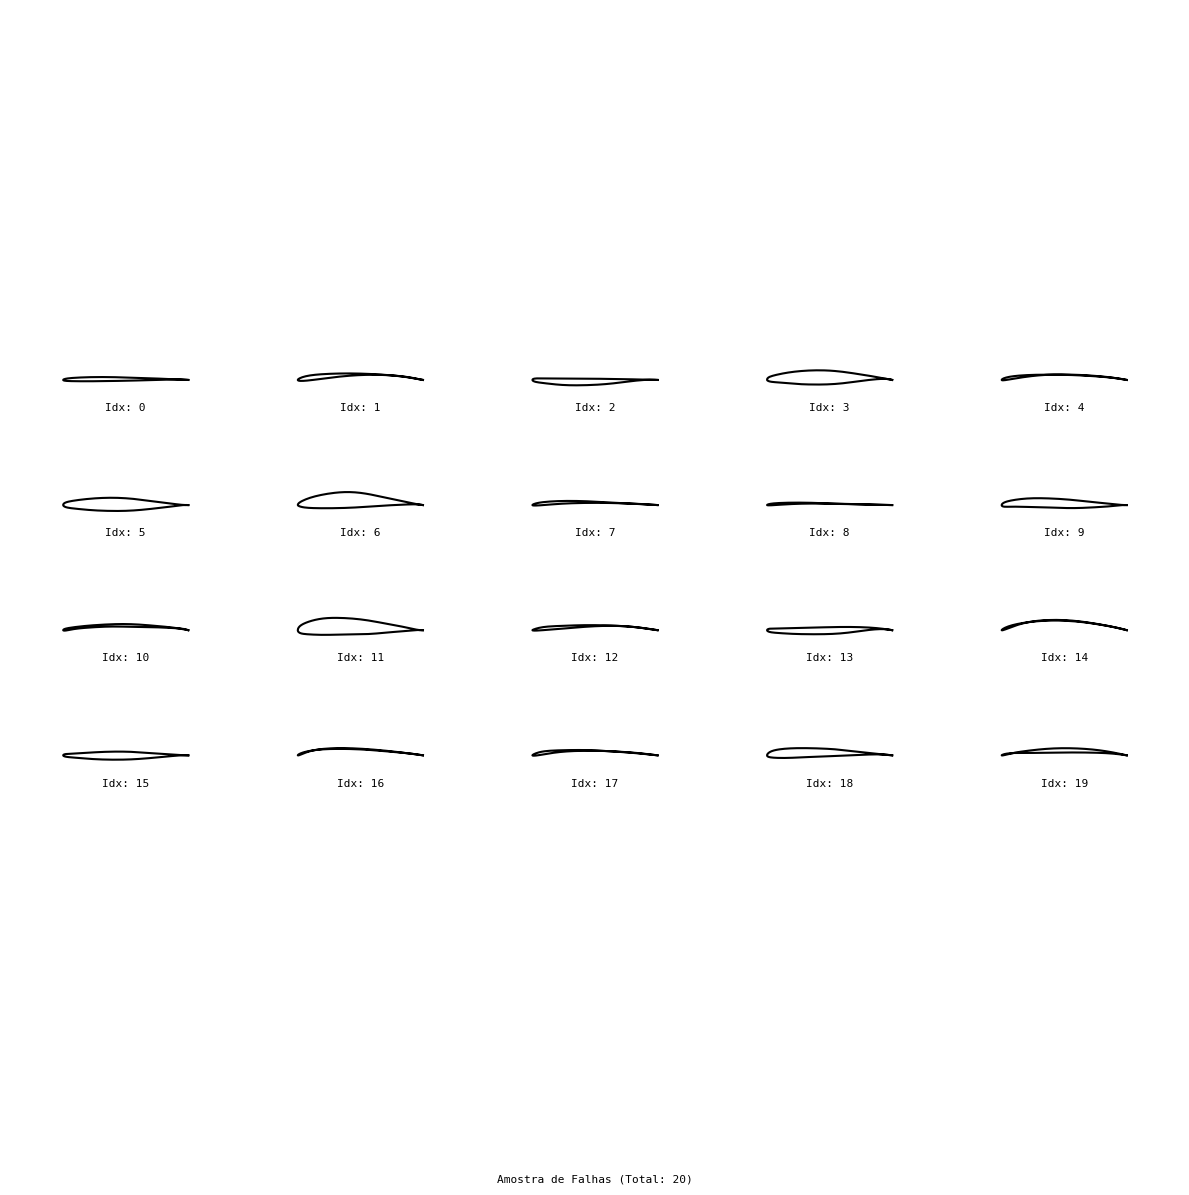

Imagem salva em: /home/matsouto/Documents/py/AeroGen/images/invalid_airfoils.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Caso precise redefinir a robusta para garantir:
def check_validity_robust(airfoil_coords):
    x = airfoil_coords[:, 0]
    y = airfoil_coords[:, 1]
    le_idx = np.argmin(x)

    upper_y = y[:le_idx+1][::-1]
    upper_x = x[:le_idx+1][::-1]
    lower_y = y[le_idx:]
    lower_x = x[le_idx:]

    common_x = np.linspace(0, 1, 100)

    try:
        y_up_interp = np.interp(common_x, upper_x, upper_y)
        y_low_interp = np.interp(common_x, lower_x, lower_y)
    except ValueError:
        return False

    thickness = y_up_interp - y_low_interp
    if np.mean(thickness) < 0: thickness = -thickness # Aceita invertidos
    if np.any(thickness < -1e-4): return False
    return True

# 2. Encontrar os índices dos perfis ruins
print("Identificando perfis inválidos...")
invalid_indices = []
for i in range(len(generated_coords)):
    # Use a mesma função que te deu os 91%
    if not check_validity_robust(generated_coords[i]):
        invalid_indices.append(i)

print(f"Encontrados {len(invalid_indices)} perfis inválidos.")

# 1. Recuperar as coordenadas dos perfis ruins
bad_airfoils_coords = [generated_coords[i] for i in invalid_indices]

max_plot = 20
if len(bad_airfoils_coords) > max_plot:
    print(f"Muitos erros ({len(bad_airfoils_coords)}). Plotando os primeiros {max_plot}...")
    bad_airfoils_to_plot = bad_airfoils_coords[:max_plot]
    bad_airfoils_to_plot = random.sample(bad_airfoils_coords, max_plot)  # Amostra aleatória para diversidade
else:
    bad_airfoils_to_plot = bad_airfoils_coords

# 2. Plotar usando sua nova função
images_dir = BASE_DIR / "images"
images_dir.mkdir(parents=True, exist_ok=True)

if bad_airfoils_to_plot:
    plot_airfoil_list(
        bad_airfoils_to_plot,
        text_label=f"Amostra de Falhas (Total: {len(invalid_indices)})",
        color="black",
        linestyle="-",
        figsize=(12, 12),
        filename="invalid_airfoils.png",
        save_path=images_dir
    )
    print(f"Imagem salva em: {images_dir / 'invalid_airfoils.png'}")

In [11]:
Z_gerados = dummy_latent_vector.numpy()
mascara_validos = valid_mask
mascara_invalidos = ~valid_mask

distancias = np.linalg.norm(Z_gerados, axis=1)
dist_validos = distancias[mascara_validos].mean()
dist_invalidos = distancias[mascara_invalidos].mean()
diferenca = dist_invalidos - dist_validos

print(f"Distancia media dos validos: {dist_validos:.6f}")
print(f"Distancia media dos invalidos: {dist_invalidos:.6f}")
print(f"Diferenca (invalidos - validos): {diferenca:.6f}")

Distancia media dos validos: 3.079897
Distancia media dos invalidos: 4.448691
Diferenca (invalidos - validos): 1.368794


Perfil inválido selecionado: invalid_indices[0] -> índice global 354
Imagem salva em: /home/matsouto/Documents/py/AeroGen/images/invalid_airfoil_zoom_2.png


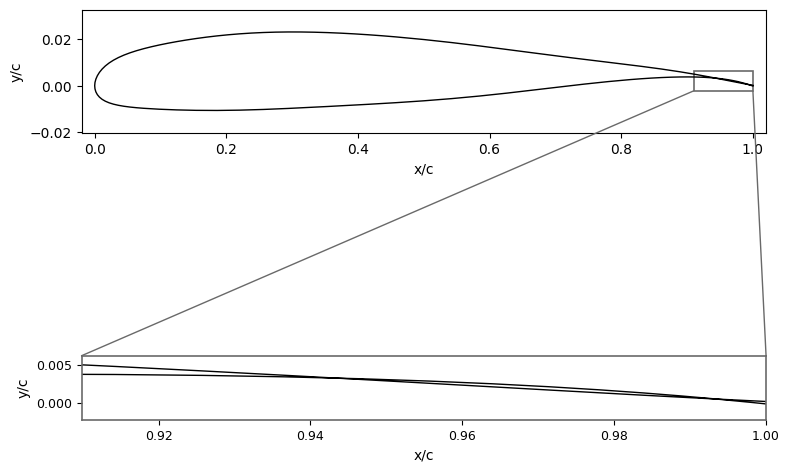

In [12]:
from matplotlib.patches import ConnectionPatch, Rectangle

INVALID_PROFILE_POSITION = -1 # posição dentro de invalid_indices
zoom_count = min(1, len(invalid_indices))

if zoom_count == 0:
    print("Nenhum perfil inválido disponível para zoom.")
else:
    selected_position = max(0, min(INVALID_PROFILE_POSITION, len(invalid_indices) - 1))
    selected_indices = [invalid_indices[selected_position]]
    selected_coords = [generated_coords[idx] for idx in selected_indices]
    print(f"Perfil inválido selecionado: invalid_indices[{selected_position}] -> índice global {selected_indices[0]}")
    images_dir = BASE_DIR / "images"
    images_dir.mkdir(parents=True, exist_ok=True)
    output_path = images_dir / "invalid_airfoil_zoom_2.png"
    global_y_min = min(float(np.min(coords[:, 1])) for coords in selected_coords)
    global_y_max = max(float(np.max(coords[:, 1])) for coords in selected_coords)
    global_y_pad = 0.08 * max(global_y_max - global_y_min, 0.12)
    main_y_limits = (global_y_min - global_y_pad, global_y_max + global_y_pad)

    fig, axes = plt.subplots(2, zoom_count, figsize=(8, 8), gridspec_kw={"height_ratios": [2.2, 1.8]}, squeeze=False)

    zoom_windows = []
    for coords in selected_coords:
        x = coords[:, 0]
        y = coords[:, 1]
        le_idx = np.argmin(x)
        upper_x = x[:le_idx + 1][::-1]
        upper_y = y[:le_idx + 1][::-1]
        lower_x = x[le_idx:]
        lower_y = y[le_idx:]
        common_x = np.linspace(0, 1, 200)
        y_up_interp = np.interp(common_x, upper_x, upper_y)
        y_low_interp = np.interp(common_x, lower_x, lower_y)
        thickness = y_up_interp - y_low_interp
        critical_idx = np.argmin(thickness)
        x_center = float(common_x[critical_idx])
        y_center = float(0.5 * (y_up_interp[critical_idx] + y_low_interp[critical_idx]))
        zoom_windows.append((x_center, y_center))

    zoom_windows_detailed = []
    zoom_x_half_window = 0.06
    for coords in selected_coords:
        x = coords[:, 0]
        y = coords[:, 1]
        le_idx = np.argmin(x)
        upper_x = x[:le_idx + 1][::-1]
        upper_y = y[:le_idx + 1][::-1]
        lower_x = x[le_idx:]
        lower_y = y[le_idx:]
        common_x = np.linspace(0, 1, 200)
        y_up_interp = np.interp(common_x, upper_x, upper_y)
        y_low_interp = np.interp(common_x, lower_x, lower_y)
        thickness = y_up_interp - y_low_interp
        critical_idx = np.argmin(thickness)
        local_thickness = abs(float(thickness[critical_idx]))
        zoom_y_half_window = max(0.004, min(0.025, 0.5 * local_thickness + 0.004))
        zoom_windows_detailed.append(zoom_y_half_window)

    for plot_idx in range(zoom_count):
        ax = axes[0, plot_idx]
        zoom_ax = axes[1, plot_idx]
        coords = selected_coords[plot_idx]
        x = coords[:, 0]
        y = coords[:, 1]
        x_center, y_center = zoom_windows[plot_idx]
        zoom_y_half_window = zoom_windows_detailed[plot_idx]

        ax.plot(x, y, color="black", linewidth=1.0)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(*main_y_limits)
        ax.set_box_aspect(0.18)
        ax.set_xlabel("x/c")
        ax.set_ylabel("y/c")

        zoom_x_min = max(0.0, x_center - zoom_x_half_window)
        zoom_x_max = min(1.0, x_center + zoom_x_half_window)
        zoom_y_min = y_center - zoom_y_half_window
        zoom_y_max = y_center + zoom_y_half_window

        zoom_box = Rectangle(
            (zoom_x_min, zoom_y_min),
            zoom_x_max - zoom_x_min,
            zoom_y_max - zoom_y_min,
            fill=False,
            edgecolor="dimgray",
            linewidth=1.2
        )
        ax.add_patch(zoom_box)

        zoom_ax.plot(x, y, color="black", linewidth=1.0)
        zoom_ax.set_aspect("equal", adjustable="box")
        zoom_ax.set_xlim(zoom_x_min, zoom_x_max)
        zoom_ax.set_ylim(zoom_y_min, zoom_y_max)
        zoom_ax.set_xlabel("x/c")
        zoom_ax.set_ylabel("y/c")
        zoom_ax.tick_params(axis="both", labelsize=9)
        for spine in zoom_ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("dimgray")
            spine.set_linewidth(1.2)

        left_connector = ConnectionPatch(
            xyA=(zoom_x_min, zoom_y_min), coordsA=ax.transData,
            xyB=(0.0, 1.0), coordsB=zoom_ax.transAxes,
            color="dimgray", linewidth=1.0
        )
        right_connector = ConnectionPatch(
            xyA=(zoom_x_max, zoom_y_min), coordsA=ax.transData,
            xyB=(1.0, 1.0), coordsB=zoom_ax.transAxes,
            color="dimgray", linewidth=1.0
        )
        fig.add_artist(left_connector)
        fig.add_artist(right_connector)

    plt.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
    print(f"Imagem salva em: {output_path}")
    plt.show()

Perfil inválido selecionado: invalid_indices[4] -> índice global 1457
Imagem salva em: /home/matsouto/Documents/py/AeroGen/images/invalid_airfoil_zoom.png


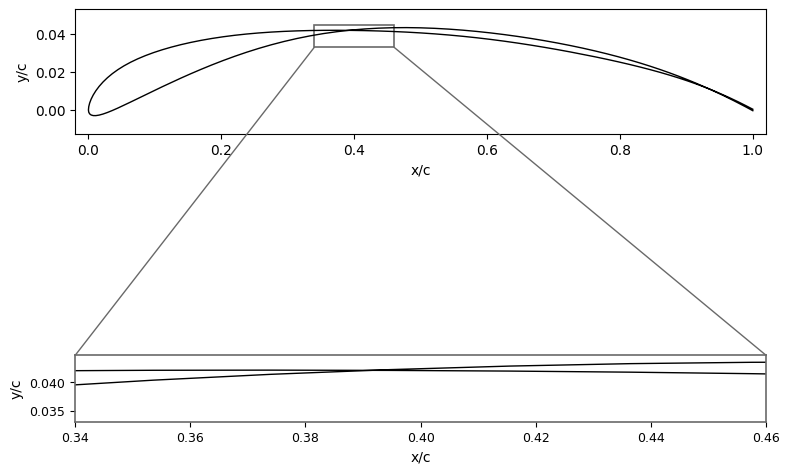

In [13]:
from matplotlib.patches import ConnectionPatch, Rectangle

INVALID_PROFILE_POSITION = 4 # posição dentro de invalid_indices
ZOOM_X_CENTER = 0.4
ZOOM_Y_OFFSET = 0.003
zoom_count = min(1, len(invalid_indices))

if zoom_count == 0:
    print("Nenhum perfil inválido disponível para zoom.")
else:
    selected_position = max(0, min(INVALID_PROFILE_POSITION, len(invalid_indices) - 1))
    selected_indices = [invalid_indices[selected_position]]
    selected_coords = [generated_coords[idx] for idx in selected_indices]
    print(f"Perfil inválido selecionado: invalid_indices[{selected_position}] -> índice global {selected_indices[0]}")
    images_dir = BASE_DIR / "images"
    images_dir.mkdir(parents=True, exist_ok=True)
    output_path = images_dir / "invalid_airfoil_zoom.png"
    global_y_min = min(float(np.min(coords[:, 1])) for coords in selected_coords)
    global_y_max = max(float(np.max(coords[:, 1])) for coords in selected_coords)
    global_y_pad = 0.08 * max(global_y_max - global_y_min, 0.12)
    main_y_limits = (global_y_min - global_y_pad, global_y_max + global_y_pad)

    fig, axes = plt.subplots(2, zoom_count, figsize=(8, 8), gridspec_kw={"height_ratios": [2.2, 1.8]}, squeeze=False)

    zoom_windows = []
    for coords in selected_coords:
        x = coords[:, 0]
        y = coords[:, 1]
        le_idx = np.argmin(x)
        upper_x = x[:le_idx + 1][::-1]
        upper_y = y[:le_idx + 1][::-1]
        lower_x = x[le_idx:]
        lower_y = y[le_idx:]
        common_x = np.linspace(0, 1, 200)
        y_up_interp = np.interp(common_x, upper_x, upper_y)
        y_low_interp = np.interp(common_x, lower_x, lower_y)
        thickness = y_up_interp - y_low_interp
        critical_idx = np.argmin(thickness)
        x_center = float(np.clip(ZOOM_X_CENTER, 0.0, 1.0))
        y_center = float(0.5 * (y_up_interp[critical_idx] + y_low_interp[critical_idx]) + ZOOM_Y_OFFSET)
        zoom_windows.append((x_center, y_center))

    zoom_windows_detailed = []
    zoom_x_half_window = 0.06
    for coords in selected_coords:
        x = coords[:, 0]
        y = coords[:, 1]
        le_idx = np.argmin(x)
        upper_x = x[:le_idx + 1][::-1]
        upper_y = y[:le_idx + 1][::-1]
        lower_x = x[le_idx:]
        lower_y = y[le_idx:]
        common_x = np.linspace(0, 1, 200)
        y_up_interp = np.interp(common_x, upper_x, upper_y)
        y_low_interp = np.interp(common_x, lower_x, lower_y)
        thickness = y_up_interp - y_low_interp
        critical_idx = np.argmin(thickness)
        local_thickness = abs(float(thickness[critical_idx]))
        zoom_y_half_window = max(0.004, min(0.025, 0.5 * local_thickness + 0.004))
        zoom_windows_detailed.append(zoom_y_half_window)

    for plot_idx in range(zoom_count):
        ax = axes[0, plot_idx]
        zoom_ax = axes[1, plot_idx]
        coords = selected_coords[plot_idx]
        x = coords[:, 0]
        y = coords[:, 1]
        x_center, y_center = zoom_windows[plot_idx]
        zoom_y_half_window = zoom_windows_detailed[plot_idx]

        ax.plot(x, y, color="black", linewidth=1.0)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(*main_y_limits)
        ax.set_box_aspect(0.18)
        ax.set_xlabel("x/c")
        ax.set_ylabel("y/c")

        zoom_x_min = max(0.0, x_center - zoom_x_half_window)
        zoom_x_max = min(1.0, x_center + zoom_x_half_window)
        zoom_y_min = y_center - zoom_y_half_window
        zoom_y_max = y_center + zoom_y_half_window

        zoom_box = Rectangle(
            (zoom_x_min, zoom_y_min),
            zoom_x_max - zoom_x_min,
            zoom_y_max - zoom_y_min,
            fill=False,
            edgecolor="dimgray",
            linewidth=1.2
        )
        ax.add_patch(zoom_box)

        zoom_ax.plot(x, y, color="black", linewidth=1.0)
        zoom_ax.set_aspect("equal", adjustable="box")
        zoom_ax.set_xlim(zoom_x_min, zoom_x_max)
        zoom_ax.set_ylim(zoom_y_min, zoom_y_max)
        zoom_ax.set_xlabel("x/c")
        zoom_ax.set_ylabel("y/c")
        zoom_ax.tick_params(axis="both", labelsize=9)
        for spine in zoom_ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("dimgray")
            spine.set_linewidth(1.2)

        left_connector = ConnectionPatch(
            xyA=(zoom_x_min, zoom_y_min), coordsA=ax.transData,
            xyB=(0.0, 1.0), coordsB=zoom_ax.transAxes,
            color="dimgray", linewidth=1.0
        )
        right_connector = ConnectionPatch(
            xyA=(zoom_x_max, zoom_y_min), coordsA=ax.transData,
            xyB=(1.0, 1.0), coordsB=zoom_ax.transAxes,
            color="dimgray", linewidth=1.0
        )
        fig.add_artist(left_connector)
        fig.add_artist(right_connector)

    plt.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
    print(f"Imagem salva em: {output_path}")
    plt.show()

### Smoothness (VOD)


DATASET GROUND TRUTH VOD (Real)
Mean VOD: 0.00000505
Std Dev:  0.00000521
Min VOD:  0.00000012
Max VOD:  0.00014404


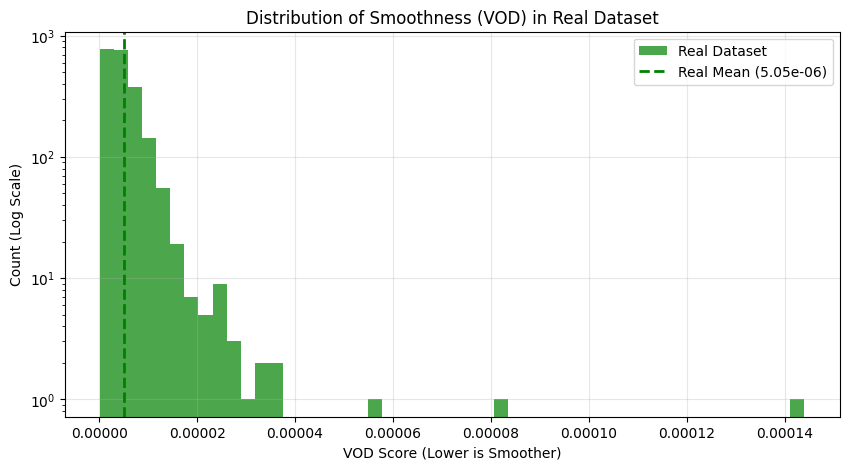

In [14]:
# ============================================================================
# 1. DATASET GROUND TRUTH VOD (SMOOTHNESS)
# ============================================================================
# VOD (Variance of Differences) measures the "roughness" of the curve.
# Lower values = Smoother airfoils.

train_df = pd.read_json(TRAIN_DATA_PATH)

# Concatenating train and validation dataframes
full_df = pd.concat([train_df, val_df], ignore_index=True)

# Converting coordinates from list to numpy arrays
full_df["coordinates"] = full_df["coordinates"].apply(np.array)

full_df["vod"] = full_df["coordinates"].apply(compute_vod_numpy)

vod_real = full_df["vod"].values

mean_vod_real = np.mean(vod_real)
std_vod_real = np.std(vod_real)
min_vod_real = np.min(vod_real)
max_vod_real = np.max(vod_real)

print("\n" + "="*40)
print("DATASET GROUND TRUTH VOD (Real)")
print("="*40)
print(f"Mean VOD: {mean_vod_real:.8f}")  # Target Baseline
print(f"Std Dev:  {std_vod_real:.8f}")
print(f"Min VOD:  {min_vod_real:.8f}")
print(f"Max VOD:  {max_vod_real:.8f}")
print("="*40)

# Plot Histogram - Real Data
plt.figure(figsize=(10, 5))
plt.hist(vod_real, bins=50, color='green', alpha=0.7, log=True, label="Real Dataset")
plt.axvline(x=mean_vod_real, color='green', linestyle='dashed', linewidth=2, label=f'Real Mean ({mean_vod_real:.2e})')
plt.title("Distribution of Smoothness (VOD) in Real Dataset")
plt.xlabel("VOD Score (Lower is Smoother)")
plt.ylabel("Count (Log Scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Generating 2170 airfoils...
Analyzing smoothness of 2170 generated airfoils...

GENERATED MODEL VOD (VAE)
Mean VOD: 0.00000501
Std Dev:  0.00000381
Min VOD:  0.00000030
Max VOD:  0.00003655


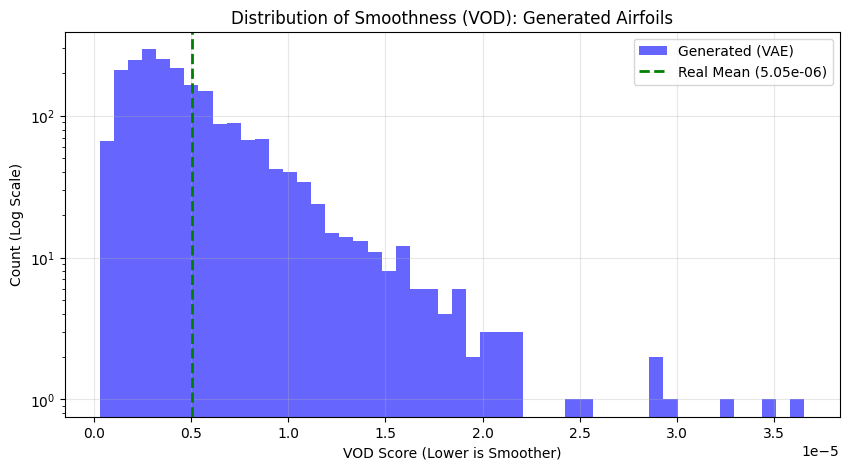

In [15]:
# ============================================================================
# 2. GENERATED MODEL VOD
# ============================================================================

BATCH_SIZE = full_df.shape[0] # Generate same number as dataset size
print(f"Generating {BATCH_SIZE} airfoils...")

dummy_latent_vector = tf.random.normal((BATCH_SIZE, LATENT_DIM))

w_norm, p_norm = vae.decoder(dummy_latent_vector)

w_norm = tf.reshape(w_norm, [-1, 2 * NPV])

w_phys, p_phys = vae.scaler.inverse_transform(w_norm.numpy(), p_norm.numpy())

w_phys_t = tf.convert_to_tensor(w_phys, dtype=tf.float32)
p_phys_t = tf.convert_to_tensor(p_phys, dtype=tf.float32)

w_phys_reshaped = tf.reshape(w_phys_t, [-1, 2, NPV])

coords = vae.decoder.cst_transform(w_phys_reshaped, p_phys_t).numpy()

print(f"Analyzing smoothness of {len(coords)} generated airfoils...")

# A. Extract Y coordinates
y_coords_gen = coords[:, :, 1] 

# B. Calculate First Differences (Slopes)
diffs_gen = np.diff(y_coords_gen, axis=1)

# C. Calculate Variance of Differences (VOD)
vod_gen = np.var(diffs_gen, axis=1)

mean_vod_gen = np.mean(vod_gen)
std_vod_gen = np.std(vod_gen)
min_vod_gen = np.min(vod_gen)
max_vod_gen = np.max(vod_gen)

print("\n" + "="*40)
print("GENERATED MODEL VOD (VAE)")
print("="*40)
print(f"Mean VOD: {mean_vod_gen:.8f}") 
print(f"Std Dev:  {std_vod_gen:.8f}")
print(f"Min VOD:  {min_vod_gen:.8f}")
print(f"Max VOD:  {max_vod_gen:.8f}")
print("="*40)

# Plot Histogram - Generated Data
plt.figure(figsize=(10, 5))
plt.hist(vod_gen, bins=50, color='blue', alpha=0.6, label='Generated (VAE)', log=True)
# Add a vertical line for the Dataset Mean
plt.axvline(x=mean_vod_real, color='green', linestyle='dashed', linewidth=2, label=f'Real Mean ({mean_vod_real:.2e})')
plt.title("Distribution of Smoothness (VOD): Generated Airfoils")
plt.xlabel("VOD Score (Lower is Smoother)")
plt.ylabel("Count (Log Scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [16]:
# ============================================================================
# 2.5 COMPARATIVE VOD DISTRIBUTION (TRAIN x GENERATED)
# ============================================================================

import plotly.graph_objects as go

images_dir = BASE_DIR / "images"
images_dir.mkdir(parents=True, exist_ok=True)
output_path = images_dir / f"vae_vod_comparison_{RUN_ID}_epoch_{EPOCH}.png"
viridis_color = "#2D6A4F"
vod_scale = 1e6
vod_train_scaled = vod_real * vod_scale
vod_gen_scaled = vod_gen * vod_scale
mean_vod_train_scaled = mean_vod_real * vod_scale
mean_vod_gen_scaled = mean_vod_gen * vod_scale

all_vod_scaled = np.concatenate([vod_train_scaled, vod_gen_scaled])
bin_count = 100
bin_start = float(np.min(all_vod_scaled))
bin_end = float(np.max(all_vod_scaled))
bin_size = (bin_end - bin_start) / bin_count if bin_end > bin_start else 1.0
shared_bins = dict(start=bin_start, end=bin_end, size=bin_size)

fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=vod_train_scaled,
        xbins=shared_bins,
        name=f"VOD<sub>train</sub> | média = {mean_vod_train_scaled:.3f}",
        marker=dict(color="slategrey", line=dict(color="white", width=1)),
        opacity=0.75
    )
)
fig.add_trace(
    go.Histogram(
        x=vod_gen_scaled,
        xbins=shared_bins,
        name=f"VOD<sub>gen</sub> | média = {mean_vod_gen_scaled:.3f}",
        marker=dict(color=viridis_color, line=dict(color="white", width=1)),
        opacity=0.6
    )
)

fig.update_xaxes(title_text="VOD (×10⁻⁶)", range=[0, 30])
fig.update_yaxes(title_text="Contagem")
fig.update_layout(
    template="plotly_white",
    barmode="overlay",
    width=900,
    height=500,
    margin=dict(l=60, r=30, t=20, b=60),
    legend=dict(title="", x=0.98, y=0.98, xanchor="right", yanchor="top")
)

fig.write_image(output_path, format="png", width=900, height=500, scale=300 / 96)
fig.show()
print(f"Saved VOD comparison figure to: {output_path}")

Saved VOD comparison figure to: /home/matsouto/Documents/py/AeroGen/images/vae_vod_comparison_20260516-232746_epoch_100.png


In [17]:
# ============================================================================
# 3. RELATIVE VOD (Comparison)
# ============================================================================
# Relative VOD = Mean Generated VOD / Mean Real VOD
# Ideally, we want this to be close to 1.0 (matching reality) or < 1.0 (smoother than reality).
# > 1.0 means the generated airfoils are noisier/rougher than real ones.

relative_vod = mean_vod_gen / mean_vod_real

print("\n" + "="*40)
print(f"RELATIVE VOD (Rv)")
print("="*40)
print(f"Real Mean VOD:      {mean_vod_real:.8f}")
print(f"Generated Mean VOD: {mean_vod_gen:.8f}")
print("-" * 40)
print(f"Rv SCORE: {relative_vod:.4f}")
print("="*40)

# --- INTERPRETATION (Note: Logic is INVERTED compared to Diversity) ---
# For Diversity: Higher is Better.
# For VOD (Noise): Lower is Better.

if relative_vod <= 1.0:
    print(f"✅ EXCELLENT. Rv={relative_vod:.2f} <= 1.0")
    print("   The generated airfoils are as smooth (or smoother) than the real dataset.")
elif relative_vod <= 1.5:
    print(f"✅ GOOD. Rv={relative_vod:.2f}")
    print("   The generated airfoils have acceptable smoothness (slightly noisier than reference).")
    print("   XFoil should handle this fine.")
else:
    print(f"⚠️  WARNING. Rv={relative_vod:.2f} > 1.5")
    print("   The generated airfoils are significantly noisier/rougher than the training data.")
    print("   This might cause convergence issues in XFoil.")


RELATIVE VOD (Rv)
Real Mean VOD:      0.00000505
Generated Mean VOD: 0.00000501
----------------------------------------
Rv SCORE: 0.9919
✅ EXCELLENT. Rv=0.99 <= 1.0
   The generated airfoils are as smooth (or smoother) than the real dataset.


### Diversity

In [18]:
import numpy as np
from scipy.spatial.distance import cdist

def calculate_diversity_score(data_A, data_B=None):
    """
    Calculates the diversity score D as defined in the prompt.
    
    Formula: D(Y^(1), Y^(2)) = 1/n1 * sum_{i=1}^{n1} (min_{j=1}^{n2} ||Y^(1)_i - Y^(2)_j||^2)^0.5
    
    Parameters:
    -----------
    data_A : np.ndarray
        Dataset Y^(1) of shape (n1, n_features).
    data_B : np.ndarray, optional
        Dataset Y^(2) of shape (n2, n_features). 
        If None, calculates self-diversity D(Y^(1), Y^(1)) with diagonal exclusion.
        
    Returns:
    --------
    float
        The calculated diversity score.
    """
    # Ensure inputs are 2D arrays (flattening airfoils if necessary)
    A = np.asarray(data_A)
    if A.ndim > 2:
        A = A.reshape(A.shape[0], -1)
        
    if data_B is None:
        # Calculate Self-Diversity: D(Y, Y)
        # We must exclude the distance to itself (which is 0) to get a meaningful metric
        dists = cdist(A, A, metric='euclidean')
        np.fill_diagonal(dists, np.inf) # Ignore self-distance
        
        # min_{j} || Y_i - Y_j ||
        min_dists = np.min(dists, axis=1)
        
        # 1/n * sum(...)
        return np.mean(min_dists)
        
    else:
        # Calculate Diversity between datasets: D(Y^(1), Y^(2))
        B = np.asarray(data_B)
        if B.ndim > 2:
            B = B.reshape(B.shape[0], -1)
            
        dists = cdist(A, B, metric='euclidean')
        
        # min_{j} || Y^(1)_i - Y^(2)_j ||
        min_dists = np.min(dists, axis=1)
        
        return np.mean(min_dists)

def calculate_relative_diversity(generated_data, original_data):
    """
    Calculates Relative Diversity (RD).
    
    Definition: Ratio of the diversity of the generated dataset to the 
    self-diversity of the airfoil dataset.
    RD = D(Y_gen, Y_gen) / D(Y_orig, Y_orig)
    
    Interpretation:
    - RD > 1: Generated dataset is more diverse than original.
    - RD < 1: Generated dataset is less diverse (mode collapse).
    """
    div_gen = calculate_diversity_score(generated_data, None)
    div_orig = calculate_diversity_score(original_data, None)
    
    # Avoid division by zero
    if div_orig == 0:
        return np.inf
        
    return div_gen / div_orig

# ============================================================================
# DIVERSITY ANALYSIS 
# ============================================================================
print("Preparing data for diversity calculation...")

# 1. Obter dados brutos
real_coords_array = np.stack(full_df["coordinates"].values) # (N_real, 149, 2)
gen_coords_array = coords # (N_gen, 149, 2)

n_real = len(real_coords_array)
n_gen = len(gen_coords_array)

print(f"Original Real Size:      {n_real}")
print(f"Original Generated Size: {n_gen}")

# 2. DEFINIR O TAMANHO DE CORTE (O MÍNIMO ENTRE OS DOIS)
# Isso garante densidade comparável
n_samples = min(n_real, n_gen)

print(f"\nEqualizing sample sizes to N={n_samples} to avoid density bias...")

# 3. SUBSAMPLING (Aleatório para garantir justiça)
# Embaralha índices e pega os primeiros N
indices_real = np.random.choice(n_real, n_samples, replace=False)
indices_gen = np.random.choice(n_gen, n_samples, replace=False)

real_subset = real_coords_array[indices_real]
gen_subset = gen_coords_array[indices_gen]

print("\nCalculating Diversity Metrics on Equalized Subsets...")

# --- CÁLCULOS COM SUBSETS IGUAIS ---

# 1. Self-Diversity Real
div_real = calculate_diversity_score(real_subset)

# 2. Self-Diversity Gerado
div_gen = calculate_diversity_score(gen_subset)

# 3. Relative Diversity
rd_score = div_gen / div_real

# --- PRINT RESULTS ---
print("\n" + "="*40)
print(f"DIVERSITY METRICS RESULTS (N={n_samples})")
print("="*40)
print(f"Real Data Diversity:      {div_real:.6f}")
print(f"Generated Data Diversity: {div_gen:.6f}")
print("-" * 40)
print(f"Relative Diversity (RD):  {rd_score:.6f}")
print("="*40)

# --- INTERPRETATION ---
if rd_score >= 1.0:
    print(f"✅ EXCELLENT. RD={rd_score:.2f} >= 1.0")
    print("   The model explores the design space better than the training set.")
elif rd_score >= 0.8:
    print(f"✅ GOOD. RD={rd_score:.2f}")
    print("   Diversity is comparable to the real data.")
else:
    print(f"⚠️  WARNING. RD={rd_score:.2f}")
    print("   Potential Mode Collapse or generated samples are too clustered.")

Preparing data for diversity calculation...
Original Real Size:      2170
Original Generated Size: 2170

Equalizing sample sizes to N=2170 to avoid density bias...

Calculating Diversity Metrics on Equalized Subsets...

DIVERSITY METRICS RESULTS (N=2170)
Real Data Diversity:      0.032899
Generated Data Diversity: 0.033437
----------------------------------------
Relative Diversity (RD):  1.016362
✅ EXCELLENT. RD=1.02 >= 1.0
   The model explores the design space better than the training set.


In [19]:
# ============================================================================
# 2.5 COMPARATIVE DIVERSITY DISTRIBUTION (TRAIN x GENERATED)
# ============================================================================

import plotly.graph_objects as go

real_flat = real_subset.reshape(real_subset.shape[0], -1)
gen_flat = gen_subset.reshape(gen_subset.shape[0], -1)

dists_real = cdist(real_flat, real_flat, metric='euclidean')
np.fill_diagonal(dists_real, np.inf)
nn_real = np.min(dists_real, axis=1)

dists_gen = cdist(gen_flat, gen_flat, metric='euclidean')
np.fill_diagonal(dists_gen, np.inf)
nn_gen = np.min(dists_gen, axis=1)

mean_nn_real = float(np.mean(nn_real))
mean_nn_gen = float(np.mean(nn_gen))

images_dir = BASE_DIR / 'images'
images_dir.mkdir(parents=True, exist_ok=True)
output_path = images_dir / f'vae_diversity_comparison_{RUN_ID}_epoch_{EPOCH}.png'
viridis_color = '#2D6A4F'

all_nn = np.concatenate([nn_real, nn_gen])
bin_count = 100
bin_start = float(np.min(all_nn))
bin_end = float(np.max(all_nn))
bin_size = (bin_end - bin_start) / bin_count if bin_end > bin_start else 1.0
shared_bins = dict(start=bin_start, end=bin_end, size=bin_size)

fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=nn_real,
        xbins=shared_bins,
        name=f'D<sub>train</sub> | média = {mean_nn_real:.3f}',
        marker=dict(color='slategrey', line=dict(color='white', width=1)),
        opacity=0.75
    )
)
fig.add_trace(
    go.Histogram(
        x=nn_gen,
        xbins=shared_bins,
        name=f'D<sub>gen</sub> | média = {mean_nn_gen:.3f}',
        marker=dict(color=viridis_color, line=dict(color='white', width=1)),
        opacity=0.6
    )
)

fig.update_xaxes(title_text='min<sub>j</sub> ||Y<sub>i</sub> - Y<sub>j</sub>||', range=[0, 0.3])
fig.update_yaxes(title_text='Contagem')
fig.update_layout(
    template='plotly_white',
    barmode='overlay',
    width=900,
    height=500,
    margin=dict(l=60, r=30, t=20, b=60),
    legend=dict(title='', x=0.98, y=0.98, xanchor='right', yanchor='top')
)

fig.write_image(output_path, format='png', width=900, height=500, scale=300 / 96)
fig.show()
print(f'Saved diversity comparison figure to: {output_path}')

Saved diversity comparison figure to: /home/matsouto/Documents/py/AeroGen/images/vae_diversity_comparison_20260516-232746_epoch_100.png


### Latent Space Walk

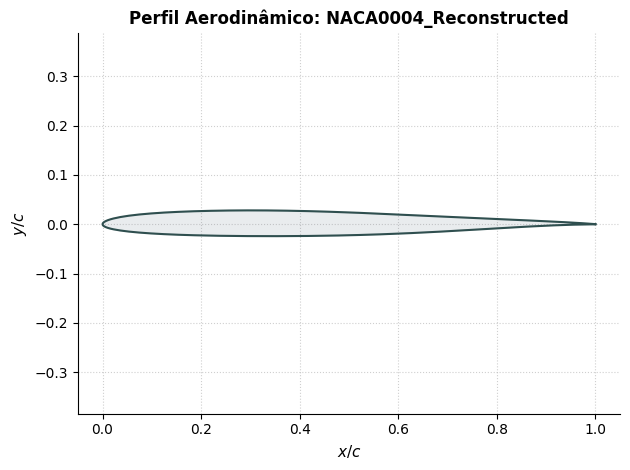

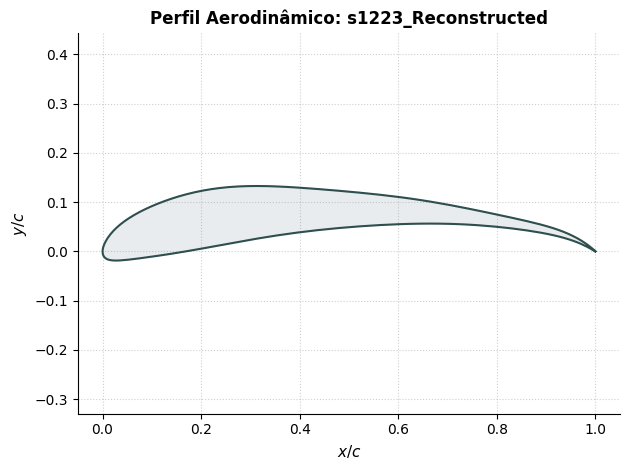

In [20]:
af1 = Airfoil(name="NACA0004").to_kulfan_airfoil(NPV)
af2 = Airfoil(name="s1223").to_kulfan_airfoil(NPV)

af1_w = np.concatenate(
    (af1.kulfan_parameters["upper_weights"], 
     af1.kulfan_parameters["lower_weights"]), 
    axis=0
)
af1_p = np.array([af1.kulfan_parameters["TE_thickness"], af1.kulfan_parameters["leading_edge_weight"]])

af2_w = np.concatenate(
    (af2.kulfan_parameters["upper_weights"], 
     af2.kulfan_parameters["lower_weights"]), 
    axis=0
)
af2_p = np.array([af2.kulfan_parameters["TE_thickness"], af2.kulfan_parameters["leading_edge_weight"]])

af1_w = af1_w.reshape(1, -1)
af1_p = af1_p.reshape(1, -1)
af2_w = af2_w.reshape(1, -1)
af2_p = af2_p.reshape(1, -1)

af1_normalized = scaler.transform(af1_w, af1_p)
af2_normalized = scaler.transform(af2_w, af2_p)

af1_normalized_tensor = tf.convert_to_tensor(af1_normalized, dtype=tf.float32)
af2_normalized_tensor = tf.convert_to_tensor(af2_normalized, dtype=tf.float32)

af1_pred_w_norm, af1_pred_p_norm = vae(af1_normalized_tensor, training=False)
af2_pred_w_norm, af2_pred_p_norm = vae(af2_normalized_tensor, training=False)

af1_pred_w, af1_pred_p = scaler.inverse_transform(af1_pred_w_norm.numpy(), af1_pred_p_norm.numpy())
af2_pred_w, af2_pred_p = scaler.inverse_transform(af2_pred_w_norm.numpy(), af2_pred_p_norm.numpy())

af1_pred_w_t = tf.reshape(tf.convert_to_tensor(af1_pred_w, dtype=tf.float32), [-1, 2, NPV])
af1_pred_p_t = tf.convert_to_tensor(af1_pred_p, dtype=tf.float32)
af2_pred_w_t = tf.reshape(tf.convert_to_tensor(af2_pred_w, dtype=tf.float32), [-1, 2, NPV])
af2_pred_p_t = tf.convert_to_tensor(af2_pred_p, dtype=tf.float32)

af1_pred_coords = vae.decoder.cst_transform(af1_pred_w_t, af1_pred_p_t).numpy()
af2_pred_coords = vae.decoder.cst_transform(af2_pred_w_t, af2_pred_p_t).numpy()

af1_reconstructed = Airfoil(coordinates=af1_pred_coords[0], name="NACA0004_Reconstructed")
af1_reconstructed.draw()
af2_reconstructed = Airfoil(coordinates=af2_pred_coords[0], name="s1223_Reconstructed")
af2_reconstructed.draw()

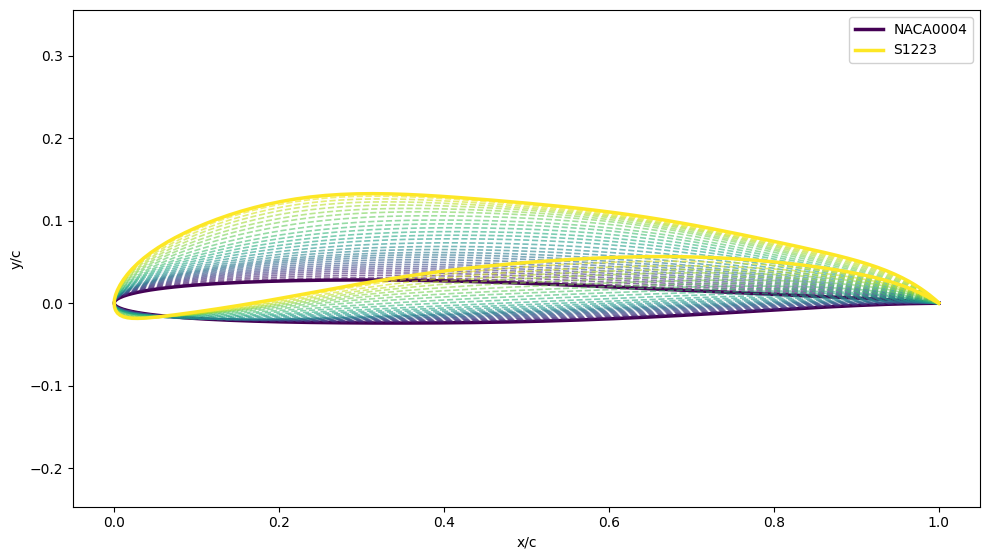

In [21]:
af1_latent_vector, _ = vae.encoder(af1_normalized_tensor)
af2_latent_vector, _ = vae.encoder(af2_normalized_tensor)

plot_latent_walk(
    vae_model=vae,
    start_point=af1_latent_vector,
    end_point=af2_latent_vector,
    num_steps=30,
    start_name="NACA0004",
    end_name="S1223",
    text_label=None,
    save_path=BASE_DIR / "images",
    filename="latent_walk_naca0004_s1223.png",
    dpi=300,
    show_axes=True,
    show_grid=False,
    colorbar=False
)

Generating GIF...
GIF saved to: latent_walk.gif


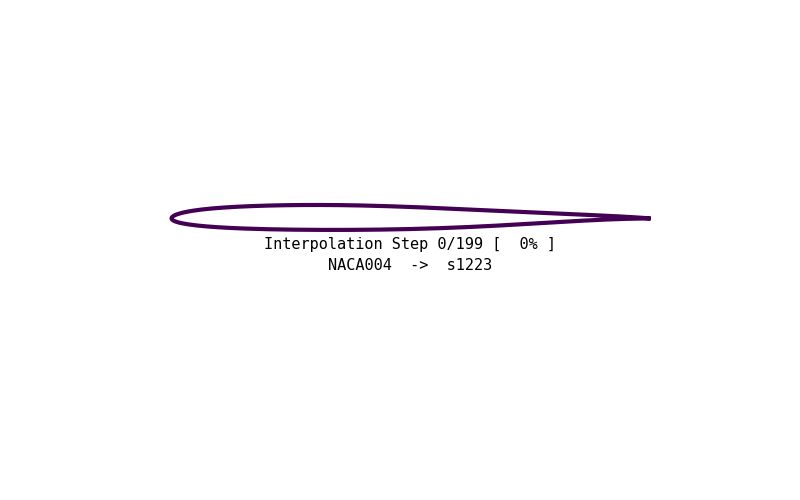

In [22]:
save_latent_walk_gif(vae, af1_latent_vector, af2_latent_vector, start_name="NACA004", end_name="s1223",  num_steps=200)

display(Image(filename="latent_walk.gif"))

### PCA e T-SNE

In [23]:
full_vectors = full_df["kulfan_parameters"].apply(
  lambda p: np.concatenate([
    p["upper_weights"],     # Upper
    p["lower_weights"],     # Lower
    [p["TE_thickness"]],    # TE
    [p["leading_edge_weight"]] # LE
    ], axis=0)).to_list()

# Convert to Tensor (Physical Units)
full_tensor_phys = tf.convert_to_tensor(full_vectors, dtype=tf.float32)
full_weights_phys = full_tensor_phys[:, : 2 * NPV]
full_params_phys = full_tensor_phys[:, 2 * NPV :]

# Normalize for Model Input
full_normalized = scaler.transform(full_weights_phys, full_params_phys)

In [24]:

import plotly.graph_objects as go

# ============================================================================
# 1. PREPARAR DADOS
# ============================================================================
print("Extraindo vetores latentes...")
z_mean, _ = vae.encoder(full_normalized)
z_mean = z_mean.numpy()

w_phys_real, p_phys_real = vae.scaler.inverse_transform(
    full_normalized[:, :2 * NPV], full_normalized[:, 2 * NPV:]
)
w_phys_real_t = tf.reshape(tf.convert_to_tensor(w_phys_real, dtype=tf.float32), [-1, 2, NPV])
p_phys_real_t = tf.convert_to_tensor(p_phys_real, dtype=tf.float32)
coords_all = vae.decoder.cst_transform(w_phys_real_t, p_phys_real_t).numpy()

common_x = np.linspace(0, 1, 200)
max_camber    = np.zeros(len(coords_all))
max_thickness = np.zeros(len(coords_all))

print("Calculando camber e espessura...")
for i, c in enumerate(coords_all):
    x, y = c[:, 0], c[:, 1]
    le = int(np.argmin(x))
    yu = np.interp(common_x, x[:le + 1][::-1], y[:le + 1][::-1])
    yl = np.interp(common_x, x[le:], y[le:])
    max_camber[i]    = float(np.max(np.abs((yu + yl) / 2.0)))
    max_thickness[i] = float(np.max(yu - yl))

# ============================================================================
# 2. PCA
# ============================================================================
print("Calculando PCA...")
pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_mean)
explained_var = pca.explained_variance_ratio_

figuras_dir = BASE_DIR / 'Figuras'
figuras_dir.mkdir(parents=True, exist_ok=True)

axis_style = dict(showline=True, linewidth=1, linecolor='black', mirror=True)
pca_abs_max = float(np.max(np.abs(z_pca))) * 1.05
pca_range = [-pca_abs_max, pca_abs_max]

# ============================================================================
# 3. PLOTAGEM — colorido por camber
# ============================================================================
fig_pca = go.Figure()

fig_pca.add_trace(go.Scatter(
    x=z_pca[:, 0], y=z_pca[:, 1], mode='markers',
    marker=dict(
        color=max_camber, colorscale='Viridis', size=4, opacity=0.7,
        colorbar=dict(title=dict(text='Camber máx.', side='right'), thickness=15, len=0.9),
    ),
    showlegend=False,
))

fig_pca.update_xaxes(title_text='Componente principal 1', range=pca_range, **axis_style)
fig_pca.update_yaxes(title_text='Componente principal 2', range=pca_range, **axis_style)
fig_pca.update_layout(
    template='plotly_white',
    width=720,
    height=650,
    margin=dict(l=60, r=80, t=20, b=60),
    showlegend=False,
)

output_pca = figuras_dir / f'latent_pca_{RUN_ID}_epoch_{EPOCH}.png'
fig_pca.write_image(output_pca, format='png', width=720, height=650, scale=300 / 96)
fig_pca.show()
print(f'Salvo: {output_pca}')


Extraindo vetores latentes...
Calculando camber e espessura...
Calculando PCA...


Salvo: /home/matsouto/Documents/py/AeroGen/Figuras/latent_pca_20260516-232746_epoch_100.png


In [25]:

import plotly.graph_objects as go

# ============================================================================
# PLOTAGEM — colorido por espessura
# ============================================================================
fig_pca_t = go.Figure()

fig_pca_t.add_trace(go.Scatter(
    x=z_pca[:, 0], y=z_pca[:, 1], mode='markers',
    marker=dict(
        color=max_thickness, colorscale='Viridis', size=4, opacity=0.7,
        colorbar=dict(title=dict(text='Espessura máx.', side='right'), thickness=15, len=0.9),
    ),
    showlegend=False,
))

fig_pca_t.update_xaxes(title_text='Componente principal 1', range=pca_range, **axis_style)
fig_pca_t.update_yaxes(title_text='Componente principal 2', range=pca_range, **axis_style)
fig_pca_t.update_layout(
    template='plotly_white',
    width=720,
    height=650,
    margin=dict(l=60, r=80, t=20, b=60),
    showlegend=False,
)

output_pca_t = figuras_dir / f'latent_pca_thickness_{RUN_ID}_epoch_{EPOCH}.png'
fig_pca_t.write_image(output_pca_t, format='png', width=720, height=650, scale=300 / 96)
fig_pca_t.show()
print(f'Salvo: {output_pca_t}')


Salvo: /home/matsouto/Documents/py/AeroGen/Figuras/latent_pca_thickness_20260516-232746_epoch_100.png


In [26]:

import plotly.graph_objects as go

# 1. PCA completo
pca_full = PCA(n_components=None)
pca_full.fit(z_mean)

# 2. Dados
variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
num_componentes = np.arange(1, len(variancia_acumulada) + 1)
n_90 = int(np.argmax(variancia_acumulada >= 0.90) + 1)

viridis_color = '#2D6A4F'
figuras_dir = BASE_DIR / 'images'
figuras_dir.mkdir(parents=True, exist_ok=True)

axis_style = dict(
    showline=True, linewidth=1, linecolor='black', mirror=True
)

# 3. Scree Plot
fig_scree = go.Figure()

fig_scree.add_trace(
    go.Scatter(
        x=num_componentes,
        y=variancia_acumulada,
        mode='lines+markers',
        marker=dict(color=viridis_color, size=6),
        line=dict(color=viridis_color, dash='dash'),
        name='Variância acumulada'
    )
)
fig_scree.add_hline(
    y=0.90,
    line=dict(color='slategrey', dash='dot', width=1.5),
    annotation_text='90%',
    annotation_position='top left',
    annotation_font=dict(color='slategrey')
)

fig_scree.update_xaxes(
    title_text='Número de componentes principais',
    tickvals=list(num_componentes),
    **axis_style
)
fig_scree.update_yaxes(
    title_text='Variância explicada acumulada',
    tickformat='.0%',
    range=[0, 1.05],
    **axis_style
)
fig_scree.update_layout(
    template='plotly_white',
    width=900,
    height=500,
    margin=dict(l=60, r=30, t=20, b=60),
    legend=dict(title='', x=0.02, y=0.98, xanchor='left', yanchor='top')
)

output_scree = figuras_dir / f'latent_scree_{RUN_ID}_epoch_{EPOCH}.png'
fig_scree.write_image(output_scree, format='png', width=900, height=500, scale=300 / 96)
fig_scree.show()
print(f'Salvo: {output_scree}')
print(f'Variância total com {len(num_componentes)} componentes: {variancia_acumulada[-1]:.2%}')
print(f'Componentes para atingir 90%: {n_90}')


Salvo: /home/matsouto/Documents/py/AeroGen/images/latent_scree_20260516-232746_epoch_100.png
Variância total com 10 componentes: 100.00%
Componentes para atingir 90%: 8


### Gaussianidade do Espaço Latente

In [27]:
# ============================================================================
# 1. Q-Q PLOT POR DIMENSÃO LATENTE
# ============================================================================
# Se os pontos caem sobre a diagonal, a dimensão segue N(0,1).

from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots

n_dims = z_mean.shape[1]
n_cols = 5
n_rows = int(np.ceil(n_dims / n_cols))

fig_qq = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=[f"z<sub>{i+1}</sub>" for i in range(n_dims)],
)

viridis_color = "#2D6A4F"
axis_style_qq = dict(showline=True, linewidth=1, linecolor="black", mirror=True)

for i in range(n_dims):
    row = i // n_cols + 1
    col = i % n_cols + 1

    (osm, osr), (slope, intercept, _) = stats.probplot(z_mean[:, i], dist="norm")
    x_line = np.array([osm[0], osm[-1]])
    y_line = slope * x_line + intercept

    fig_qq.add_trace(
        go.Scatter(
            x=osm, y=osr, mode="markers",
            marker=dict(color=viridis_color, size=3, opacity=0.5),
            showlegend=False,
        ),
        row=row, col=col,
    )
    fig_qq.add_trace(
        go.Scatter(
            x=x_line, y=y_line, mode="lines",
            line=dict(color="crimson", width=1.5),
            showlegend=False,
        ),
        row=row, col=col,
    )

fig_qq.update_xaxes(title_text="Quantis teóricos N(0,1)", **axis_style_qq)
fig_qq.update_yaxes(title_text="Quantis observados", **axis_style_qq)
fig_qq.update_layout(
    template="plotly_white",
    width=1200,
    height=500,
    margin=dict(l=50, r=30, t=50, b=50),
    title_text="Q-Q Plot — Dimensões do Espaço Latente vs. N(0,1)",
)

output_qq = figuras_dir / f"latent_qqplot_{RUN_ID}_epoch_{EPOCH}.png"
fig_qq.write_image(output_qq, format="png", width=1200, height=500, scale=300 / 96)
fig_qq.show()
print(f"Salvo: {output_qq}")

Salvo: /home/matsouto/Documents/py/AeroGen/images/latent_qqplot_20260516-232746_epoch_100.png


In [28]:
# ============================================================================
# 2. HISTOGRAMAS POR DIMENSÃO COM CURVA N(0,1) SOBREPOSTA
# ============================================================================

x_ref = np.linspace(-4, 4, 300)
gauss_ref = stats.norm.pdf(x_ref)

# Calcular escala Y global para uniformizar todos os subgráficos
all_hist_max = max(
    np.histogram(z_mean[:, i], bins=40, density=True)[0].max()
    for i in range(n_dims)
)
y_max_global = max(all_hist_max, gauss_ref.max()) * 1.12

fig_hist = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=[f"z<sub>{i+1}</sub>" for i in range(n_dims)],
)

for i in range(n_dims):
    row = i // n_cols + 1
    col = i % n_cols + 1

    fig_hist.add_trace(
        go.Histogram(
            x=z_mean[:, i],
            histnorm="probability density",
            nbinsx=40,
            marker=dict(color=viridis_color, opacity=0.65, line=dict(color="white", width=0.5)),
            showlegend=False,
            name="z latente",
        ),
        row=row, col=col,
    )
    fig_hist.add_trace(
        go.Scatter(
            x=x_ref, y=gauss_ref, mode="lines",
            line=dict(color="crimson", width=1.5, dash="dash"),
            showlegend=(i == 0),
            name="N(0,1)",
        ),
        row=row, col=col,
    )

# Escalas uniformes em X e Y
fig_hist.update_xaxes(range=[-4, 4], **axis_style_qq)
fig_hist.update_yaxes(title_text="", range=[0, y_max_global], **axis_style_qq)

# "Densidade" apenas no primeiro subgráfico de cada fileira
for r in range(1, n_rows + 1):
    fig_hist.update_yaxes(title_text="Densidade", row=r, col=1)

fig_hist.update_layout(
    template="plotly_white",
    width=1200,
    height=500,
    margin=dict(l=50, r=30, t=50, b=50),
    legend=dict(x=1.01, y=1.0, xanchor="left"),
)

output_hist = figuras_dir / f"latent_histograms_{RUN_ID}_epoch_{EPOCH}.png"
fig_hist.write_image(output_hist, format="png", width=1200, height=500, scale=300 / 96)
fig_hist.show()
print(f"Salvo: {output_hist}")

Salvo: /home/matsouto/Documents/py/AeroGen/images/latent_histograms_20260516-232746_epoch_100.png


In [29]:
# ============================================================================
# 3. TESTE KOLMOGOROV-SMIRNOV POR DIMENSÃO
# ============================================================================
# H0: a dimensão segue N(0,1) (normalizada).
# p > 0.05 → não há evidência para rejeitar gaussianidade.

from scipy.stats import kstest

print(f"{'Dim':<8} {'Média':>10} {'Std':>10} {'KS stat':>10} {'p-valor':>12} {'Resultado'}")
print("=" * 65)

ks_stats, ks_pvals, ks_results = [], [], []
for i in range(n_dims):
    z_i = z_mean[:, i]
    z_norm = (z_i - z_i.mean()) / z_i.std()
    stat, pval = kstest(z_norm, "norm")
    resultado = "✓ Gaussiana" if pval > 0.05 else "✗ Rejeita H0"
    ks_stats.append(stat)
    ks_pvals.append(pval)
    ks_results.append(resultado)
    print(f"z_{i+1:<6} {z_i.mean():>10.4f} {z_i.std():>10.4f} {stat:>10.4f} {pval:>12.4f}  {resultado}")

print("=" * 65)
n_gauss = sum(1 for r in ks_results if "✓" in r)
print(f"\n{n_gauss}/{n_dims} dimensões não rejeitam gaussianidade (α=0.05)")

# Exportar tabela como figura Plotly para o artigo
fig_ks = go.Figure(data=[go.Table(
    header=dict(
        values=["Dimensão", "Média", "Std", "KS stat", "p-valor", "Resultado"],
        fill_color="slategrey",
        font=dict(color="white", size=12),
        align="center",
    ),
    cells=dict(
        values=[
            [f"z_{i+1}" for i in range(n_dims)],
            [f"{z_mean[:, i].mean():.4f}" for i in range(n_dims)],
            [f"{z_mean[:, i].std():.4f}" for i in range(n_dims)],
            [f"{s:.4f}" for s in ks_stats],
            [f"{p:.4f}" for p in ks_pvals],
            ks_results,
        ],
        fill_color=[["white" if "✓" in r else "#ffe0e0" for r in ks_results]],
        align="center",
        font=dict(size=11),
    ),
)])
fig_ks.update_layout(
    template="plotly_white",
    width=900,
    height=60 + 35 * n_dims,
    margin=dict(l=10, r=10, t=10, b=10),
)

output_ks = figuras_dir / f"latent_ks_test_{RUN_ID}_epoch_{EPOCH}.png"
fig_ks.write_image(output_ks, format="png", width=900, height=60 + 35 * n_dims, scale=300 / 96)
fig_ks.show()
print(f"\nSalvo: {output_ks}")

Dim           Média        Std    KS stat      p-valor Resultado
z_1          0.0273     0.7937     0.0294       0.0460  ✗ Rejeita H0
z_2         -0.0181     0.9400     0.0270       0.0830  ✓ Gaussiana
z_3         -0.0513     0.7478     0.0586       0.0000  ✗ Rejeita H0
z_4          0.0146     0.7385     0.0618       0.0000  ✗ Rejeita H0
z_5         -0.0300     0.4465     0.0665       0.0000  ✗ Rejeita H0
z_6          0.0272     0.9179     0.0332       0.0161  ✗ Rejeita H0
z_7         -0.0483     0.9816     0.0494       0.0000  ✗ Rejeita H0
z_8          0.0551     0.9704     0.0659       0.0000  ✗ Rejeita H0
z_9          0.1790     0.6682     0.0594       0.0000  ✗ Rejeita H0
z_10        -0.0996     0.8422     0.0641       0.0000  ✗ Rejeita H0

1/10 dimensões não rejeitam gaussianidade (α=0.05)



Salvo: /home/matsouto/Documents/py/AeroGen/images/latent_ks_test_20260516-232746_epoch_100.png


In [30]:

import re
import io, base64, matplotlib.figure
from matplotlib.backends.backend_agg import FigureCanvasAgg

# ============================================================================
# PCA — FAMÍLIA NACA SIMÉTRICA (NACA 0006 → NACA 0080, forma exata naca00XX)
# ============================================================================

names_all = full_df['airfoil_name'].values

def _naca_sym_thickness(name):
    m = re.fullmatch(r'naca00(\d{2})', name.strip(), re.IGNORECASE)
    if m:
        return int(m.group(1))
    return None

thicknesses = [_naca_sym_thickness(n) for n in names_all]
naca_sym_mask = np.array([
    (t is not None and 6 <= t <= 80) for t in thicknesses
], dtype=bool)

idx_sym  = np.where(naca_sym_mask)[0]
idx_rest = np.where(~naca_sym_mask)[0]

names_sym  = names_all[idx_sym]
names_rest = names_all[idx_rest]

print(f"Perfis NACA simétricos (naca00XX, 06–80): {len(idx_sym)}")
print("Perfis:", sorted(names_sym.tolist()))

# --- Extremos: menor e maior PC1 dentro da família simétrica ----------------
sym_pc1 = z_pca[idx_sym, 0]
_i_min  = idx_sym[np.argmin(sym_pc1)]
_i_max  = idx_sym[np.argmax(sym_pc1)]
name_sym_min = names_all[_i_min]
name_sym_max = names_all[_i_max]
print(f"Extremo min PC1: {name_sym_min}  |  Extremo max PC1: {name_sym_max}")

# --- Helper: miniatura de perfil em preto -----------------------------------
def _airfoil_b64(coords, fig_w=2.4, fig_h=0.75):
    x, y = coords[:, 0], coords[:, 1]
    fig_tmp = matplotlib.figure.Figure(figsize=(fig_w, fig_h), facecolor='none')
    ax_tmp  = fig_tmp.add_subplot(111)
    ax_tmp.plot(x, y, color='black', lw=1.2)
    ax_tmp.set_aspect('equal')
    ax_tmp.axis('off')
    canvas = FigureCanvasAgg(fig_tmp)
    buf = io.BytesIO()
    canvas.print_png(buf)
    return 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

img_sym_min = _airfoil_b64(coords_all[_i_min])
img_sym_max = _airfoil_b64(coords_all[_i_max])

# --- Figura ------------------------------------------------------------------
fig_pca_naca = go.Figure()

# Fundo: todos os demais em cinza
fig_pca_naca.add_trace(go.Scatter(
    x=z_pca[idx_rest, 0], y=z_pca[idx_rest, 1],
    mode='markers',
    marker=dict(color='#b0b0b0', size=4, opacity=0.5),
    name='Demais',
    showlegend=True,
    text=names_rest,
    hovertemplate='%{text}<extra></extra>',
))

# Frente: NACA simétricos com o verde padrão do trabalho
fig_pca_naca.add_trace(go.Scatter(
    x=z_pca[idx_sym, 0], y=z_pca[idx_sym, 1],
    mode='markers+text',
    marker=dict(color=viridis_color, size=8, opacity=0.95,
                line=dict(color='white', width=0.8)),
    text=names_sym,
    textposition='top center',
    textfont=dict(size=9, color=viridis_color),
    name='NACA simétrica',
    showlegend=True,
    hovertemplate='%{text}<extra></extra>',
))

fig_pca_naca.update_xaxes(
    title_text='Componente principal 1',
    range=pca_range, **axis_style
)
fig_pca_naca.update_yaxes(
    title_text='Componente principal 2',
    range=pca_range, **axis_style
)
fig_pca_naca.update_layout(
    template='plotly_white',
    width=800,
    height=700,
    margin=dict(l=60, r=30, t=20, b=60),
    showlegend=False,
    hoverlabel=dict(bgcolor='white', font_size=12),
    images=[
        dict(
            source=img_sym_min,
            xref='paper', yref='paper',
            x=0.02, y=0.24,
            sizex=0.24, sizey=0.13,
            xanchor='left', yanchor='top',
            layer='above',
        ),
        dict(
            source=img_sym_max,
            xref='paper', yref='paper',
            x=0.98, y=0.86,
            sizex=0.24, sizey=0.13,
            xanchor='right', yanchor='top',
            layer='above',
        ),
    ],
    annotations=[
        dict(
            text=name_sym_min,
            xref='paper', yref='paper',
            x=0.14, y=0.11,
            xanchor='center', yanchor='top',
            showarrow=False,
            font=dict(size=9, color='black'),
        ),
        dict(
            text=name_sym_max,
            xref='paper', yref='paper',
            x=0.86, y=0.73,
            xanchor='center', yanchor='top',
            showarrow=False,
            font=dict(size=9, color='black'),
        ),
    ],
)

output_pca_naca = figuras_dir / f'latent_pca_naca_sym_{RUN_ID}_epoch_{EPOCH}.png'
fig_pca_naca.write_image(output_pca_naca, format='png', width=800, height=700, scale=300 / 96)
fig_pca_naca.show()
print(f'Salvo: {output_pca_naca}')


Perfis NACA simétricos (naca00XX, 06–80): 17
Perfis: ['naca0006', 'naca0007', 'naca0008', 'naca0010', 'naca0011', 'naca0012', 'naca0013', 'naca0014', 'naca0015', 'naca0018', 'naca0021', 'naca0024', 'naca0030', 'naca0040', 'naca0050', 'naca0060', 'naca0080']
Extremo min PC1: naca0080  |  Extremo max PC1: naca0006


Salvo: /home/matsouto/Documents/py/AeroGen/images/latent_pca_naca_sym_20260516-232746_epoch_100.png


In [31]:

import re
import io, base64, matplotlib.figure
from matplotlib.backends.backend_agg import FigureCanvasAgg

# ============================================================================
# PCA — FAMÍLIA NACA XX12 (espessura 12% fixa, arqueamento e posição variáveis)
# ============================================================================

names_all = full_df['airfoil_name'].values

def _naca_xx12(name):
    m = re.fullmatch(r'naca(\d)(\d)12', name.strip(), re.IGNORECASE)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None

cam_pos_digits = [_naca_xx12(n) for n in names_all]
naca_xx12_mask = np.array([c is not None for c in cam_pos_digits], dtype=bool)

idx_cam  = np.where(naca_xx12_mask)[0]
idx_rest = np.where(~naca_xx12_mask)[0]

names_cam  = names_all[idx_cam]
names_rest = names_all[idx_rest]

order = np.argsort([(cam_pos_digits[i][0] * 10 + cam_pos_digits[i][1]) for i in idx_cam])
idx_cam_sorted   = idx_cam[order]
names_cam_sorted = names_cam[order]

print(f"Família NACA XX12: {len(idx_cam)} perfis")
print("Perfis:", names_cam_sorted.tolist())

# --- Extremos: sem camber (naca0012) e maior camber (naca6412) --------------
_j_min = int(np.where(names_all == 'naca0012')[0][0])
_j_max = int(np.where(names_all == 'naca6412')[0][0])
name_xx12_min = names_all[_j_min]
name_xx12_max = names_all[_j_max]
print(f"Sem camber: {name_xx12_min}  |  Maior camber: {name_xx12_max}")

# --- Helper: miniatura de perfil em preto -----------------------------------
def _airfoil_b64(coords, fig_w=2.4, fig_h=0.75):
    x, y = coords[:, 0], coords[:, 1]
    fig_tmp = matplotlib.figure.Figure(figsize=(fig_w, fig_h), facecolor='none')
    ax_tmp  = fig_tmp.add_subplot(111)
    ax_tmp.plot(x, y, color='black', lw=1.2)
    ax_tmp.set_aspect('equal')
    ax_tmp.axis('off')
    canvas = FigureCanvasAgg(fig_tmp)
    buf = io.BytesIO()
    canvas.print_png(buf)
    return 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

img_xx12_min = _airfoil_b64(coords_all[_j_min])
img_xx12_max = _airfoil_b64(coords_all[_j_max])

# --- Figura ------------------------------------------------------------------
fig_pca_cam = go.Figure()

# Fundo: demais pontos em cinza
fig_pca_cam.add_trace(go.Scatter(
    x=z_pca[idx_rest, 0], y=z_pca[idx_rest, 1],
    mode='markers',
    marker=dict(color='#b0b0b0', size=4, opacity=0.5),
    showlegend=False,
    text=names_rest,
    hovertemplate='%{text}<extra></extra>',
))

# Frente: NACA XX12 em verde com nome no gráfico
fig_pca_cam.add_trace(go.Scatter(
    x=z_pca[idx_cam_sorted, 0], y=z_pca[idx_cam_sorted, 1],
    mode='markers+text',
    marker=dict(color=viridis_color, size=8, opacity=0.95,
                line=dict(color='white', width=0.8)),
    text=names_cam_sorted,
    textposition='top center',
    textfont=dict(size=9, color=viridis_color),
    showlegend=False,
    hovertemplate='%{text}<extra></extra>',
))

fig_pca_cam.update_xaxes(
    title_text='Componente principal 1',
    range=pca_range, **axis_style
)
fig_pca_cam.update_yaxes(
    title_text='Componente principal 2',
    range=pca_range, **axis_style
)
fig_pca_cam.update_layout(
    template='plotly_white',
    width=800,
    height=700,
    margin=dict(l=60, r=30, t=20, b=60),
    showlegend=False,
    hoverlabel=dict(bgcolor='white', font_size=12),
    images=[
        dict(
            source=img_xx12_min,
            xref='paper', yref='paper',
            x=0.02, y=0.24,
            sizex=0.24, sizey=0.13,
            xanchor='left', yanchor='top',
            layer='above',
        ),
        dict(
            source=img_xx12_max,
            xref='paper', yref='paper',
            x=0.98, y=0.86,
            sizex=0.24, sizey=0.13,
            xanchor='right', yanchor='top',
            layer='above',
        ),
    ],
    annotations=[
        dict(
            text=name_xx12_min,
            xref='paper', yref='paper',
            x=0.14, y=0.11,
            xanchor='center', yanchor='top',
            showarrow=False,
            font=dict(size=9, color='black'),
        ),
        dict(
            text=name_xx12_max,
            xref='paper', yref='paper',
            x=0.86, y=0.73,
            xanchor='center', yanchor='top',
            showarrow=False,
            font=dict(size=9, color='black'),
        ),
    ],
)

output_pca_cam = figuras_dir / f'latent_pca_naca_xx12_{RUN_ID}_epoch_{EPOCH}.png'
fig_pca_cam.write_image(output_pca_cam, format='png', width=800, height=700, scale=300 / 96)
fig_pca_cam.show()
print(f'Salvo: {output_pca_cam}')


Família NACA XX12: 5 perfis
Perfis: ['naca0012', 'naca1412', 'naca2412', 'naca4412', 'naca6412']
Sem camber: naca0012  |  Maior camber: naca6412


Salvo: /home/matsouto/Documents/py/AeroGen/images/latent_pca_naca_xx12_20260516-232746_epoch_100.png


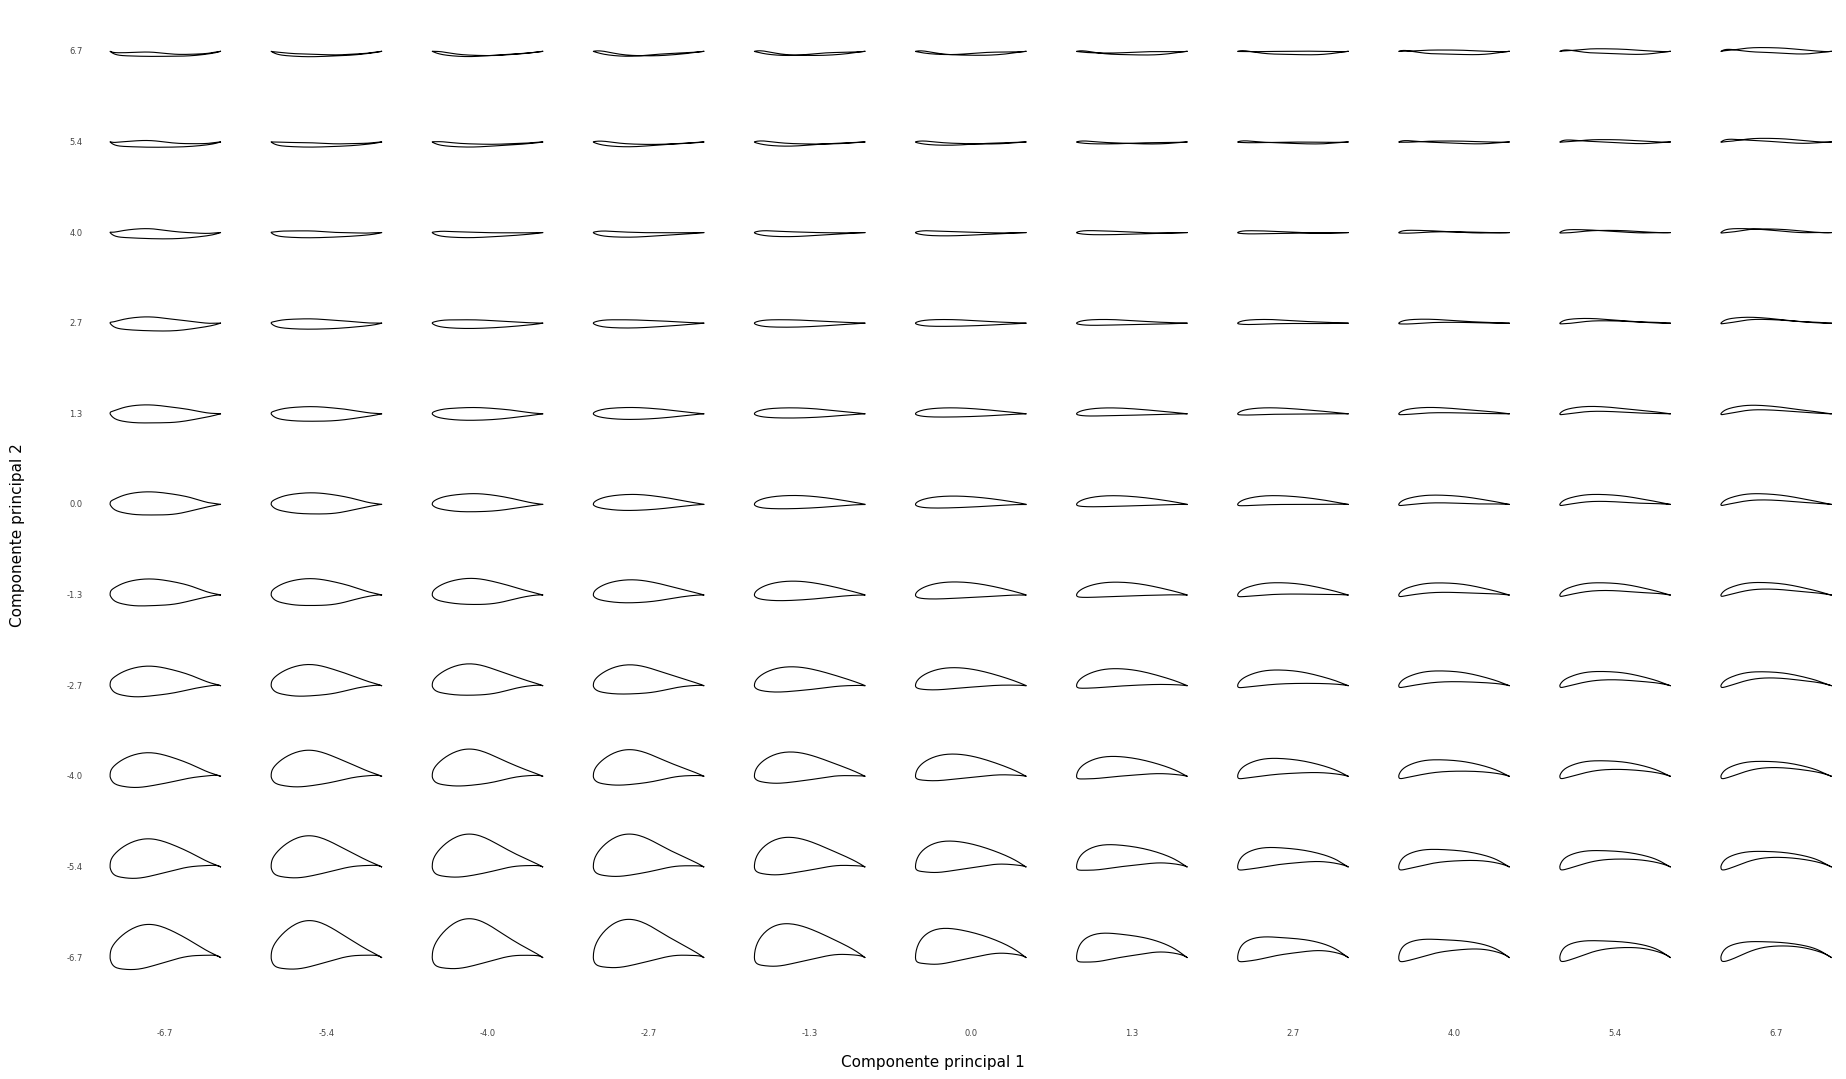

Salvo: /home/matsouto/Documents/py/AeroGen/images/latent_manifold_20260516-232746_epoch_100.png


In [32]:

# ============================================================================
# LATENT SPACE MANIFOLD — grade de geometrias nas 2 dimensões PCA
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

N_GRID     = 11        # células por eixo (N×N perfis)
GRID_LIMIT = None      # None = automático (pca_abs_max × MARGIN); ex. 5.0 para [-5, +5]
MARGIN     = 0.80      # usado apenas quando GRID_LIMIT é None

_lim     = GRID_LIMIT if GRID_LIMIT is not None else pca_abs_max * MARGIN
pc1_vals = np.linspace(-_lim, +_lim, N_GRID)
pc2_vals = np.linspace(+_lim, -_lim, N_GRID)  # topo→base

# ── 1. Montar todos os pontos da grade e decodificar em batch ────────────────
grid_pca = np.array([[pc1, pc2] for pc2 in pc2_vals for pc1 in pc1_vals],
                    dtype=np.float32)
grid_z   = pca.inverse_transform(grid_pca).astype(np.float32)

z_t      = tf.convert_to_tensor(grid_z)
w_n, p_n = vae.decoder(z_t)
w_n_flat = tf.reshape(w_n, [-1, 2 * NPV])
w_ph, p_ph = vae.scaler.inverse_transform(w_n_flat.numpy(), p_n.numpy())
w_ph_t   = tf.reshape(tf.convert_to_tensor(w_ph, dtype=tf.float32), [-1, 2, NPV])
p_ph_t   = tf.convert_to_tensor(p_ph, dtype=tf.float32)
manifold_coords = vae.decoder.cst_transform(w_ph_t, p_ph_t).numpy()  # (N²,149,2)

# ── 2. Figura matplotlib ─────────────────────────────────────────────────────
CELL_W, CELL_H = 1.6, 0.9          # tamanho de cada célula (pol)
PAD_L, PAD_R   = 0.9, 0.15
PAD_B, PAD_T   = 0.75, 0.15
fig_w = N_GRID * CELL_W + PAD_L + PAD_R
fig_h = N_GRID * CELL_H + PAD_B + PAD_T

fig_mf, axes_mf = plt.subplots(
    N_GRID, N_GRID,
    figsize=(fig_w, fig_h),
    gridspec_kw=dict(
        left   = PAD_L / fig_w,
        right  = 1 - PAD_R / fig_w,
        bottom = PAD_B / fig_h,
        top    = 1 - PAD_T / fig_h,
        wspace = 0.08,
        hspace = 0.08,
    )
)

for row in range(N_GRID):
    for col in range(N_GRID):
        ax  = axes_mf[row, col]
        idx = row * N_GRID + col
        c   = manifold_coords[idx]
        ax.plot(c[:, 0], c[:, 1], color='black', linewidth=0.8)
        ax.set_aspect('equal')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.38, 0.38)
        ax.axis('off')

        # Tick labels nas bordas: PC1 na última linha, PC2 na primeira coluna
        if row == N_GRID - 1:
            ax.text(0.5, -0.35, f'{pc1_vals[col]:.1f}',
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=6, color='#444444')
        if col == 0:
            ax.text(-0.18, 0.5, f'{pc2_vals[row]:.1f}',
                    transform=ax.transAxes, ha='right', va='center',
                    fontsize=6, color='#444444')

# Rótulos dos eixos
fig_mf.text(0.5, 0.005, 'Componente principal 1',
            ha='center', va='bottom', fontsize=11)
fig_mf.text(0.005, 0.5, 'Componente principal 2',
            ha='left', va='center', rotation='vertical', fontsize=11)

output_manifold = figuras_dir / f'latent_manifold_{RUN_ID}_epoch_{EPOCH}.png'
fig_mf.savefig(output_manifold, dpi=300, bbox_inches='tight')
plt.show()
print(f'Salvo: {output_manifold}')


In [34]:
import os
from pathlib import Path

import joblib
import numpy as np
import tensorflow as tf
from aerosandbox import Airfoil
from aerosandbox.geometry.airfoil.airfoil_families import get_kulfan_parameters

from src.vae.vae import CSTVariationalAutoencoder

# Ajuste se precisar outro modelo / pasta
RUN_ID = "20260516-232746"
EPOCH = 100
NPV = 8
LATENT_DIM = 10
NAME = "NACA0012"

root = BASE_DIR
model_dir = root / "models" / "cstvae" / RUN_ID
scaler_path = model_dir / "scaler" / "scaler.pkl"
weights_path = model_dir / "weights" / f"vae_weights_epoch_{EPOCH}.weights.h5"

# Carrega scaler e modelo
scaler = joblib.load(scaler_path)
vae = CSTVariationalAutoencoder(scaler=scaler, npv=NPV, latent_dim=LATENT_DIM)
_ = vae(tf.zeros((1, (2 * NPV) + 2), dtype=tf.float32))  # inicializa a rede
vae.load_weights(weights_path)

# Define o perfil e extrai parâmetros Kulfan
airfoil = Airfoil(name=NAME).normalize().repanel(n_points_per_side=65)
kulfan_parameters = get_kulfan_parameters(
    coordinates=airfoil.coordinates,
    n_weights_per_side=NPV,
    normalize_coordinates=True,
    use_leading_edge_modification=True,
)

raw_weights = np.concatenate(
    [kulfan_parameters["upper_weights"], kulfan_parameters["lower_weights"]],
    axis=0,
)[None, :].astype(np.float32)
raw_params = np.array(
    [[kulfan_parameters["TE_thickness"], kulfan_parameters["leading_edge_weight"]]],
    dtype=np.float32,
)

# Normaliza e codifica
normalized_input = scaler.transform(raw_weights, raw_params)
z_mean, z_log_var = vae.encoder(normalized_input)

latent_vector = z_mean[0].numpy()

print("Airfoil:", airfoil.name)
print("Latent vector:", latent_vector)
print("Latent shape:", latent_vector.shape)

Airfoil: NACA0012
Latent vector: [-0.02415213  1.4191282  -0.45865023 -0.05199685  0.43238226 -0.6527065
 -0.20710374  0.12182075  0.8461038  -0.30797744]
Latent shape: (10,)


/home/matsouto/Documents/py/AeroGen/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/matsouto/Documents/py/AeroGen/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'decoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
